# Manutenção preditiva — B-8802B: como o sistema funciona e o que ele entregou

Este notebook gera as figuras e os números da apresentação `apresentacao_simpred_b8802b.pptx`, na mesma ordem
dos slides. Usa o modelo em produção (`deploy_v2/Transpetro/B-8802B-2025`), treinado com os 12 meses de 2025,
e os dados reais do equipamento de 2022 e de 2025–26.

**Como funciona, em 4 passos** (slide 2)
1. **Aprende o normal:** um modelo de IA (autoencoder) estuda 12 meses de operação normal: como pressões,
   vibrações e temperaturas se comportam juntas.
2. **Vigia todo dia:** compara os sensores com esse normal. Se eles se afastam por mais de 1 hora, gera um alerta
   para a operação verificar.
3. **Percebe quando o normal muda:** depois de uma manutenção, o normal do equipamento pode mudar. Um monitor
   semanal (`scripts/monitor_drift.py`) percebe isso em poucos dias.
4. **Reaprende com confirmação:** a operação confirma que é um normal novo; o sistema retreina sozinho
   (`scripts/retrain_pipeline.py`) e testa o modelo novo antes de colocá-lo em uso (`scripts/battery.py`).

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import battery, monitor as mon
from transpetro_modelos.drift.detectors import CalibratedKSDetector

B = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"          # modelo em produção (treino: 2025)
B_ANTIGO = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"         # modelo de 2022
modelo = si.carregar_modelo(B)
raw = si.carregar_dados(DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv")
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))
faixa = json.loads((B / "clip_bounds.json").read_text())                  # faixa normal aprendida em 2025 (p1–p99,9)

ALARM = json.loads((B / "alarm.json").read_text())

def alertas(df):
    """Alarme do modelo em produção, instante a instante: 15 dos últimos 20 pontos (100 min) acima do limite.
    Dois cuidados com as paradas da bomba, que o pipeline filtra (pressão de descarga < 35 bar, e 90 min depois
    de religar):
    - a persistência é contada no tempo, então a janela não junta pontos de antes e de depois de uma parada;
    - o `ffill` do pipeline preenche até 20 min de cada parada repetindo o último valor; esses pontos não são
      medição real e ficam fora do alarme."""
    erro = si.prever(B, modelo, si.preprocessar(B, df))["reconstruction_error"]
    ligada = df["Pressão Descarga"].where(df["Pressão Descarga"] > 35).resample("5min").last().notna()
    real = ligada.reindex(erro.index, fill_value=False)
    acima = (erro[real] > ALARM["threshold"]).astype(float)
    janela = f"{5 * ALARM['debounce_window']}min"
    cont, n = acima.rolling(janela).sum(), acima.rolling(janela).count()
    return ((cont >= ALARM["debounce_min"]) & (n >= ALARM["debounce_window"])).reindex(erro.index, fill_value=False)

def min_duracao(al, horas=1.0):
    """Regra de 1 hora: um alarme só vira alerta se durar ≥ `horas`, e o alerta sai a partir desse ponto.
    Alarmes mais curtos (oscilação rápida que mal passa do limite) são descartados."""
    out = pd.Series(False, index=al.index); a = al[al]
    if a.empty: return out
    g = (a.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
    for _, e in a.groupby(g):
        if (e.index.max() - e.index.min()) >= pd.Timedelta(hours=horas):
            out[e.index[e.index >= e.index.min() + pd.Timedelta(hours=horas)]] = True
    return out

def episodios(al):
    a = al[al]
    if a.empty: return []
    g = (a.index.to_series().diff() > pd.Timedelta(hours=12)).cumsum()
    return [(e.index.min(), e.index.max()) for _, e in a.groupby(g)]

def horaria(df, cols):
    """Média horária só com a bomba operando; horas paradas ficam vazias (a linha quebra)."""
    return df[df["Pressão Descarga"] > 35][cols].resample("1h").mean()

COLS = ["Vibração Bomba LA", "Vibração Bomba LNA", "Temperatura Bomba LA"]
NOMES = {"Vibração Bomba LA": "Vibração mancal LA (mm/s)", "Vibração Bomba LNA": "Vibração mancal LNA (mm/s)",
         "Temperatura Bomba LA": "Temperatura mancal LA (°C)"}
rotulo = lambda c: NOMES[c].split(" (")[0].replace(" mancal", "\nmancal")
print("dados e modelo carregados")

dados e modelo carregados


## Slide 3 — Treinado com 2025, testado em 2026

2026 nunca foi usado no treino: é o teste do modelo em dados novos. A faixa verde é o normal que o modelo
aprendeu em 2025. Todos os alertas deste notebook já passam pela **regra de 1 hora**: o alarme do modelo só
vira alerta se durar pelo menos 1 hora seguida. A célula depois da figura mostra o efeito da regra em 2026.

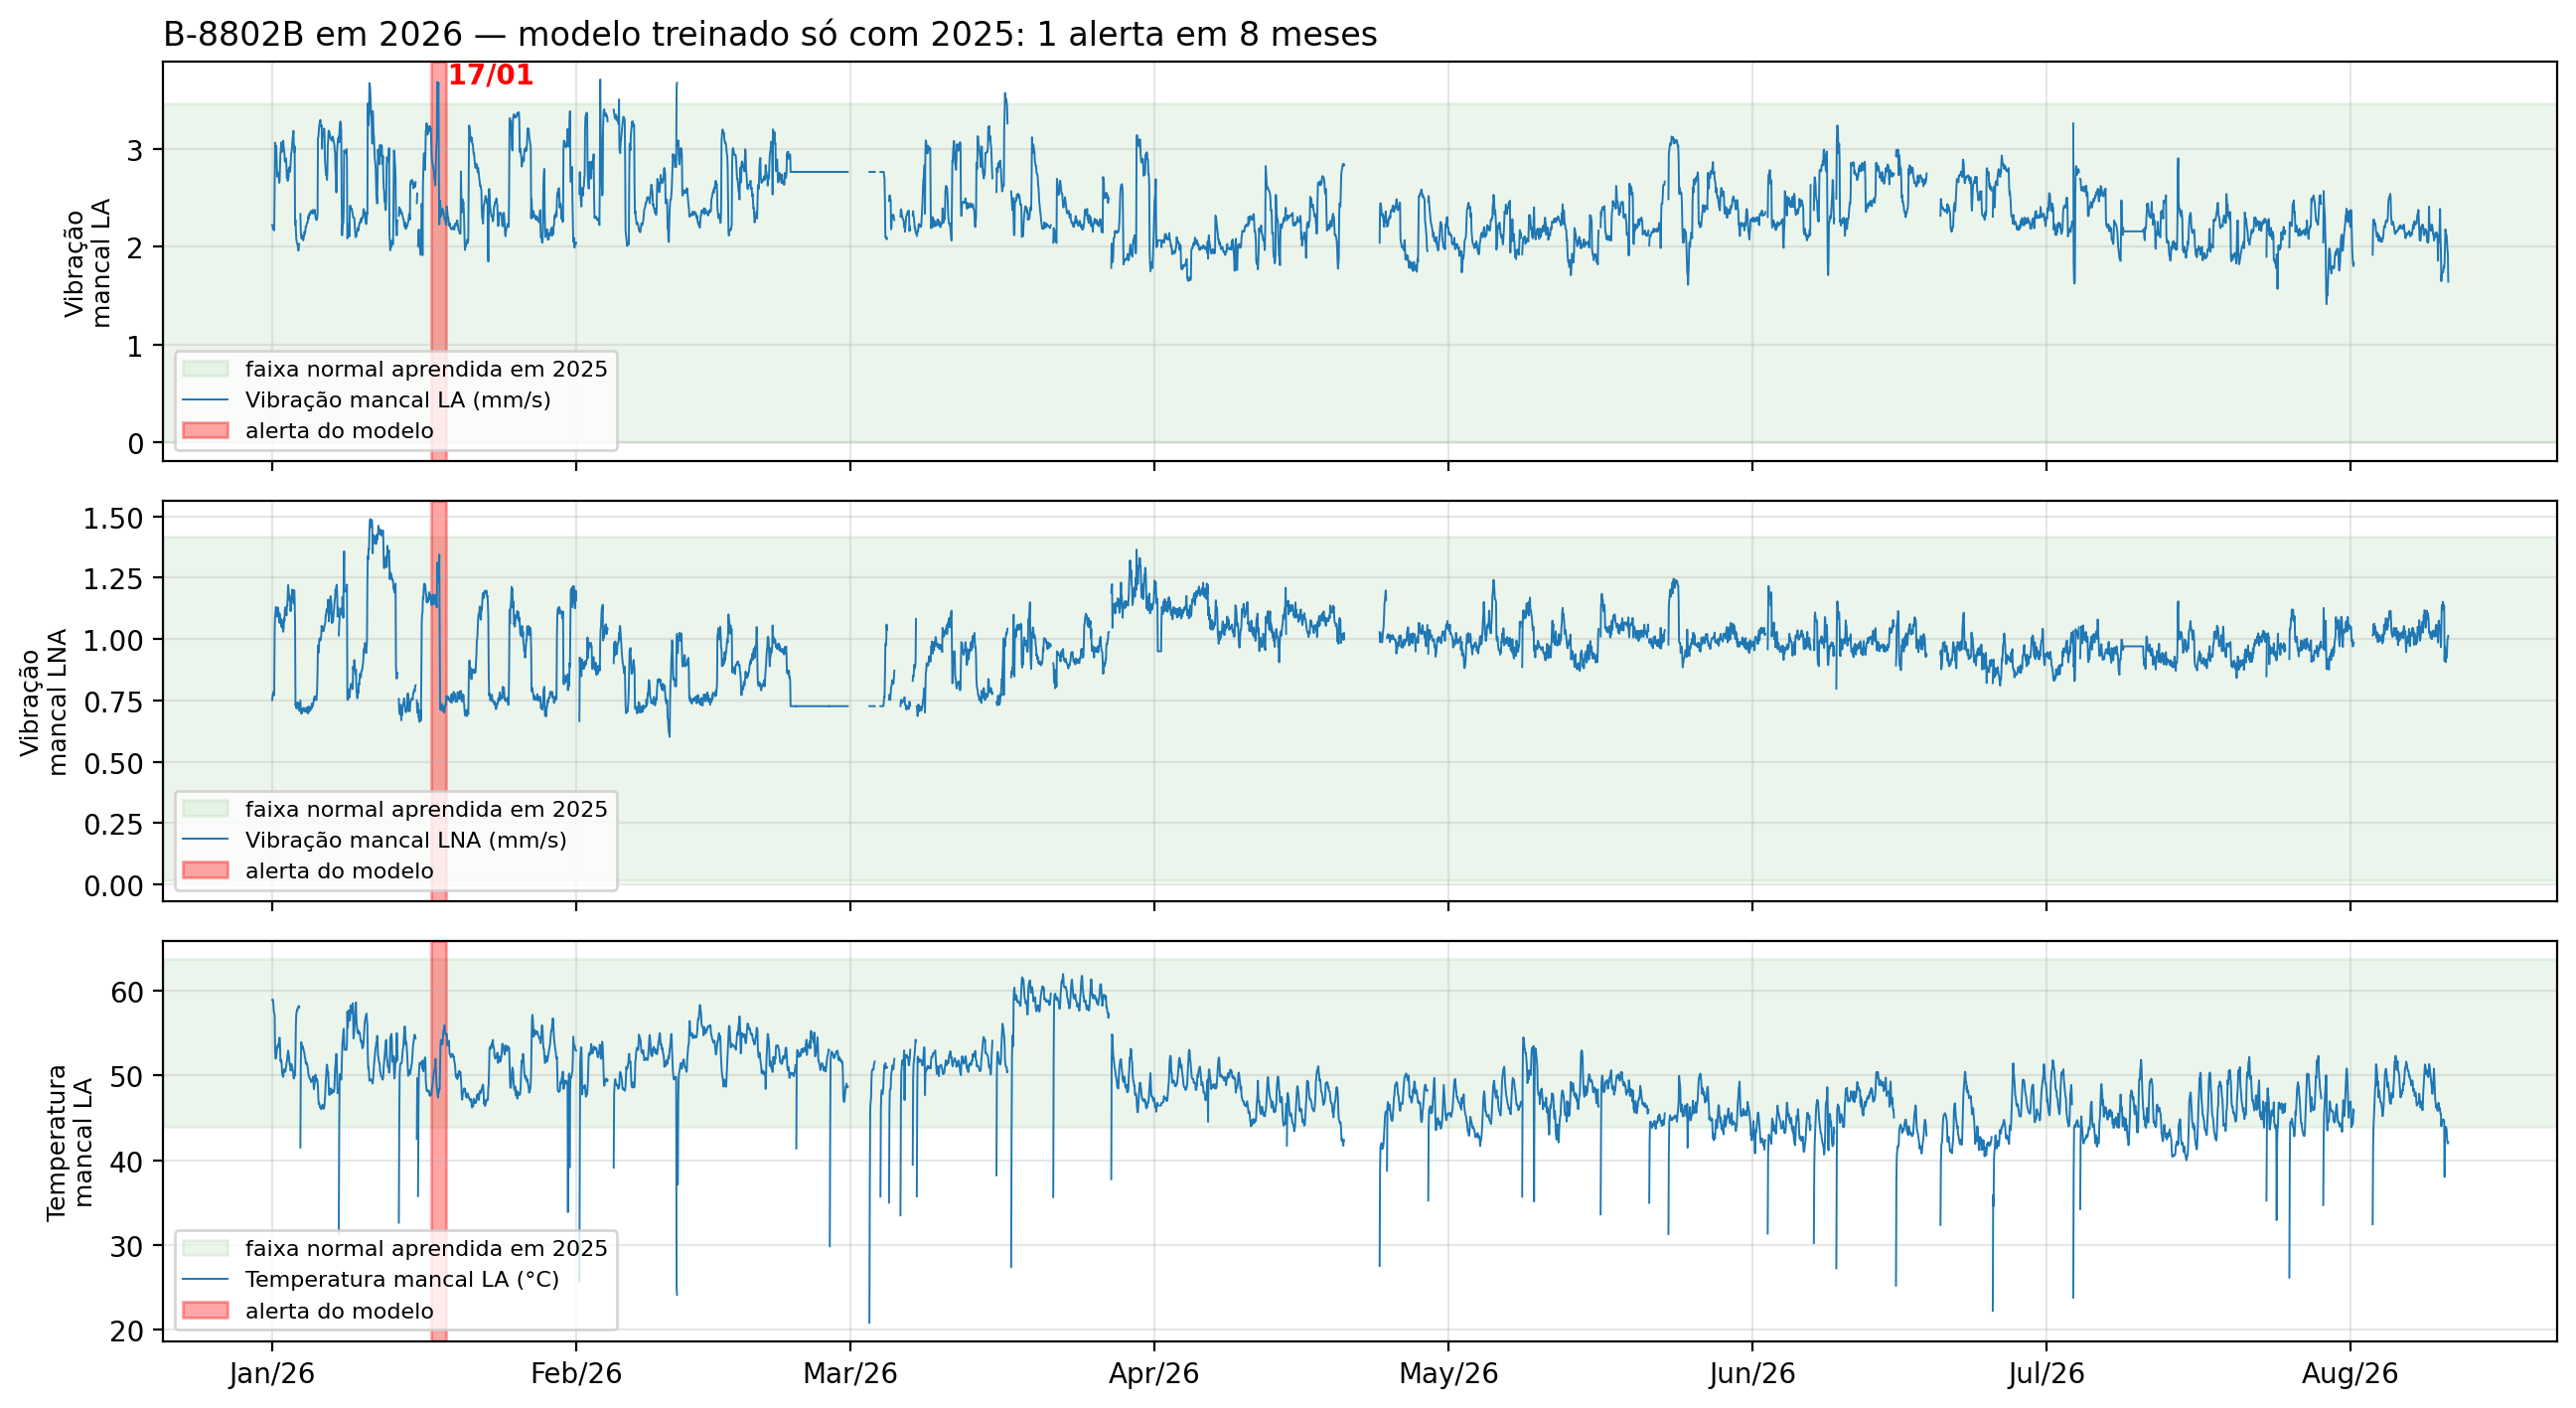

tempo sem alerta em 2026: 99.99 %   (sem a regra de 1 h: 99.95 %, 3 alertas)
alerta 17/01/2026 22:30: sensor fora da faixa normal → Vibração Bomba LA


In [2]:
al_todo = alertas(raw)
al26_sem_regra = al_todo[al_todo.index >= "2026-01-01"]
al26 = min_duracao(al_todo)[lambda s: s.index >= "2026-01-01"]
eps = episodios(al26)

h = horaria(raw.loc["2026-01-01":], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
for ax, c in zip(axes, COLS):
    lo, hi = faixa[c]
    ax.axhspan(lo, hi, color="green", alpha=0.08, label="faixa normal aprendida em 2025")
    ax.plot(h.index, h[c], linewidth=0.7, label=NOMES[c])
    for i, (a, b) in enumerate(eps):
        ax.axvspan(a - pd.Timedelta(hours=18), b + pd.Timedelta(hours=18), color="red", alpha=0.35, label="alerta do modelo" if i == 0 else None)
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
for (a, b) in eps:
    axes[0].text(a, axes[0].get_ylim()[1], f" {a:%d/%m}", color="red", fontsize=10, va="top", fontweight="bold")
axes[0].set_title(f"B-8802B em 2026 — modelo treinado só com 2025: {len(eps)} alerta{'s' if len(eps) != 1 else ''} em 8 meses", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%y")); plt.tight_layout(); plt.show()

print(f"tempo sem alerta em 2026: {100 * (1 - al26.mean()):.2f} %   (sem a regra de 1 h: {100 * (1 - al26_sem_regra.mean()):.2f} %, "
      f"{len(episodios(al26_sem_regra))} alertas)")
for a, b in eps:
    w = raw.loc[a:b]; w = w[w["Pressão Descarga"] > 35]
    fora = [c for c, (lo, hi) in faixa.items() if c in w and ((w[c] < lo) | (w[c] > hi)).mean() > 0.5]
    print(f"alerta {a:%d/%m/%Y %H:%M}: sensor fora da faixa normal → {', '.join(fora) or 'nenhum'}")

### A regra de 1 hora em 2026

Sem a regra, todo alarme do modelo vira alerta. Com ela, só os que duram 1 hora ou mais. Uma degradação real não
some em minutos (na falha de 2022 e nas falhas simuladas o alarme fica ligado por horas), então a regra corta
só oscilações curtas. O custo é o alerta sair até 1 hora mais tarde.

In [3]:
linhas = []
for a, b in episodios(al26_sem_regra):
    w = raw.loc[a:b]; w = w[w["Pressão Descarga"] > 35]
    fora = [c for c, (lo, hi) in faixa.items() if c in w and ((w[c] < lo) | (w[c] > hi)).mean() > 0.5]
    linhas.append({"alarme do modelo": f"{a:%d/%m/%Y %H:%M}", "duração": f"{(b - a).total_seconds() / 3600:.1f} h",
                   "sensor fora da faixa normal": ", ".join(fora) or "nenhum",
                   "com a regra de 1 h": "vira alerta" if al26[a:b].any() else "descartado"})
pd.DataFrame(linhas)

,alarme do modelo,duração,sensor fora da faixa normal,com a regra de 1 h
0,17/01/2026 21:30,1.2 h,Vibração Bomba LA,vira alerta
1,24/07/2026 14:35,0.3 h,nenhum,descartado
2,10/08/2026 13:20,0.7 h,nenhum,descartado


## Slide 4 — Ele detecta falha de verdade

Em 2022 a bomba falhou por uma trinca no acoplamento. O modelo foi treinado só com 2025 e nunca viu esses dados.

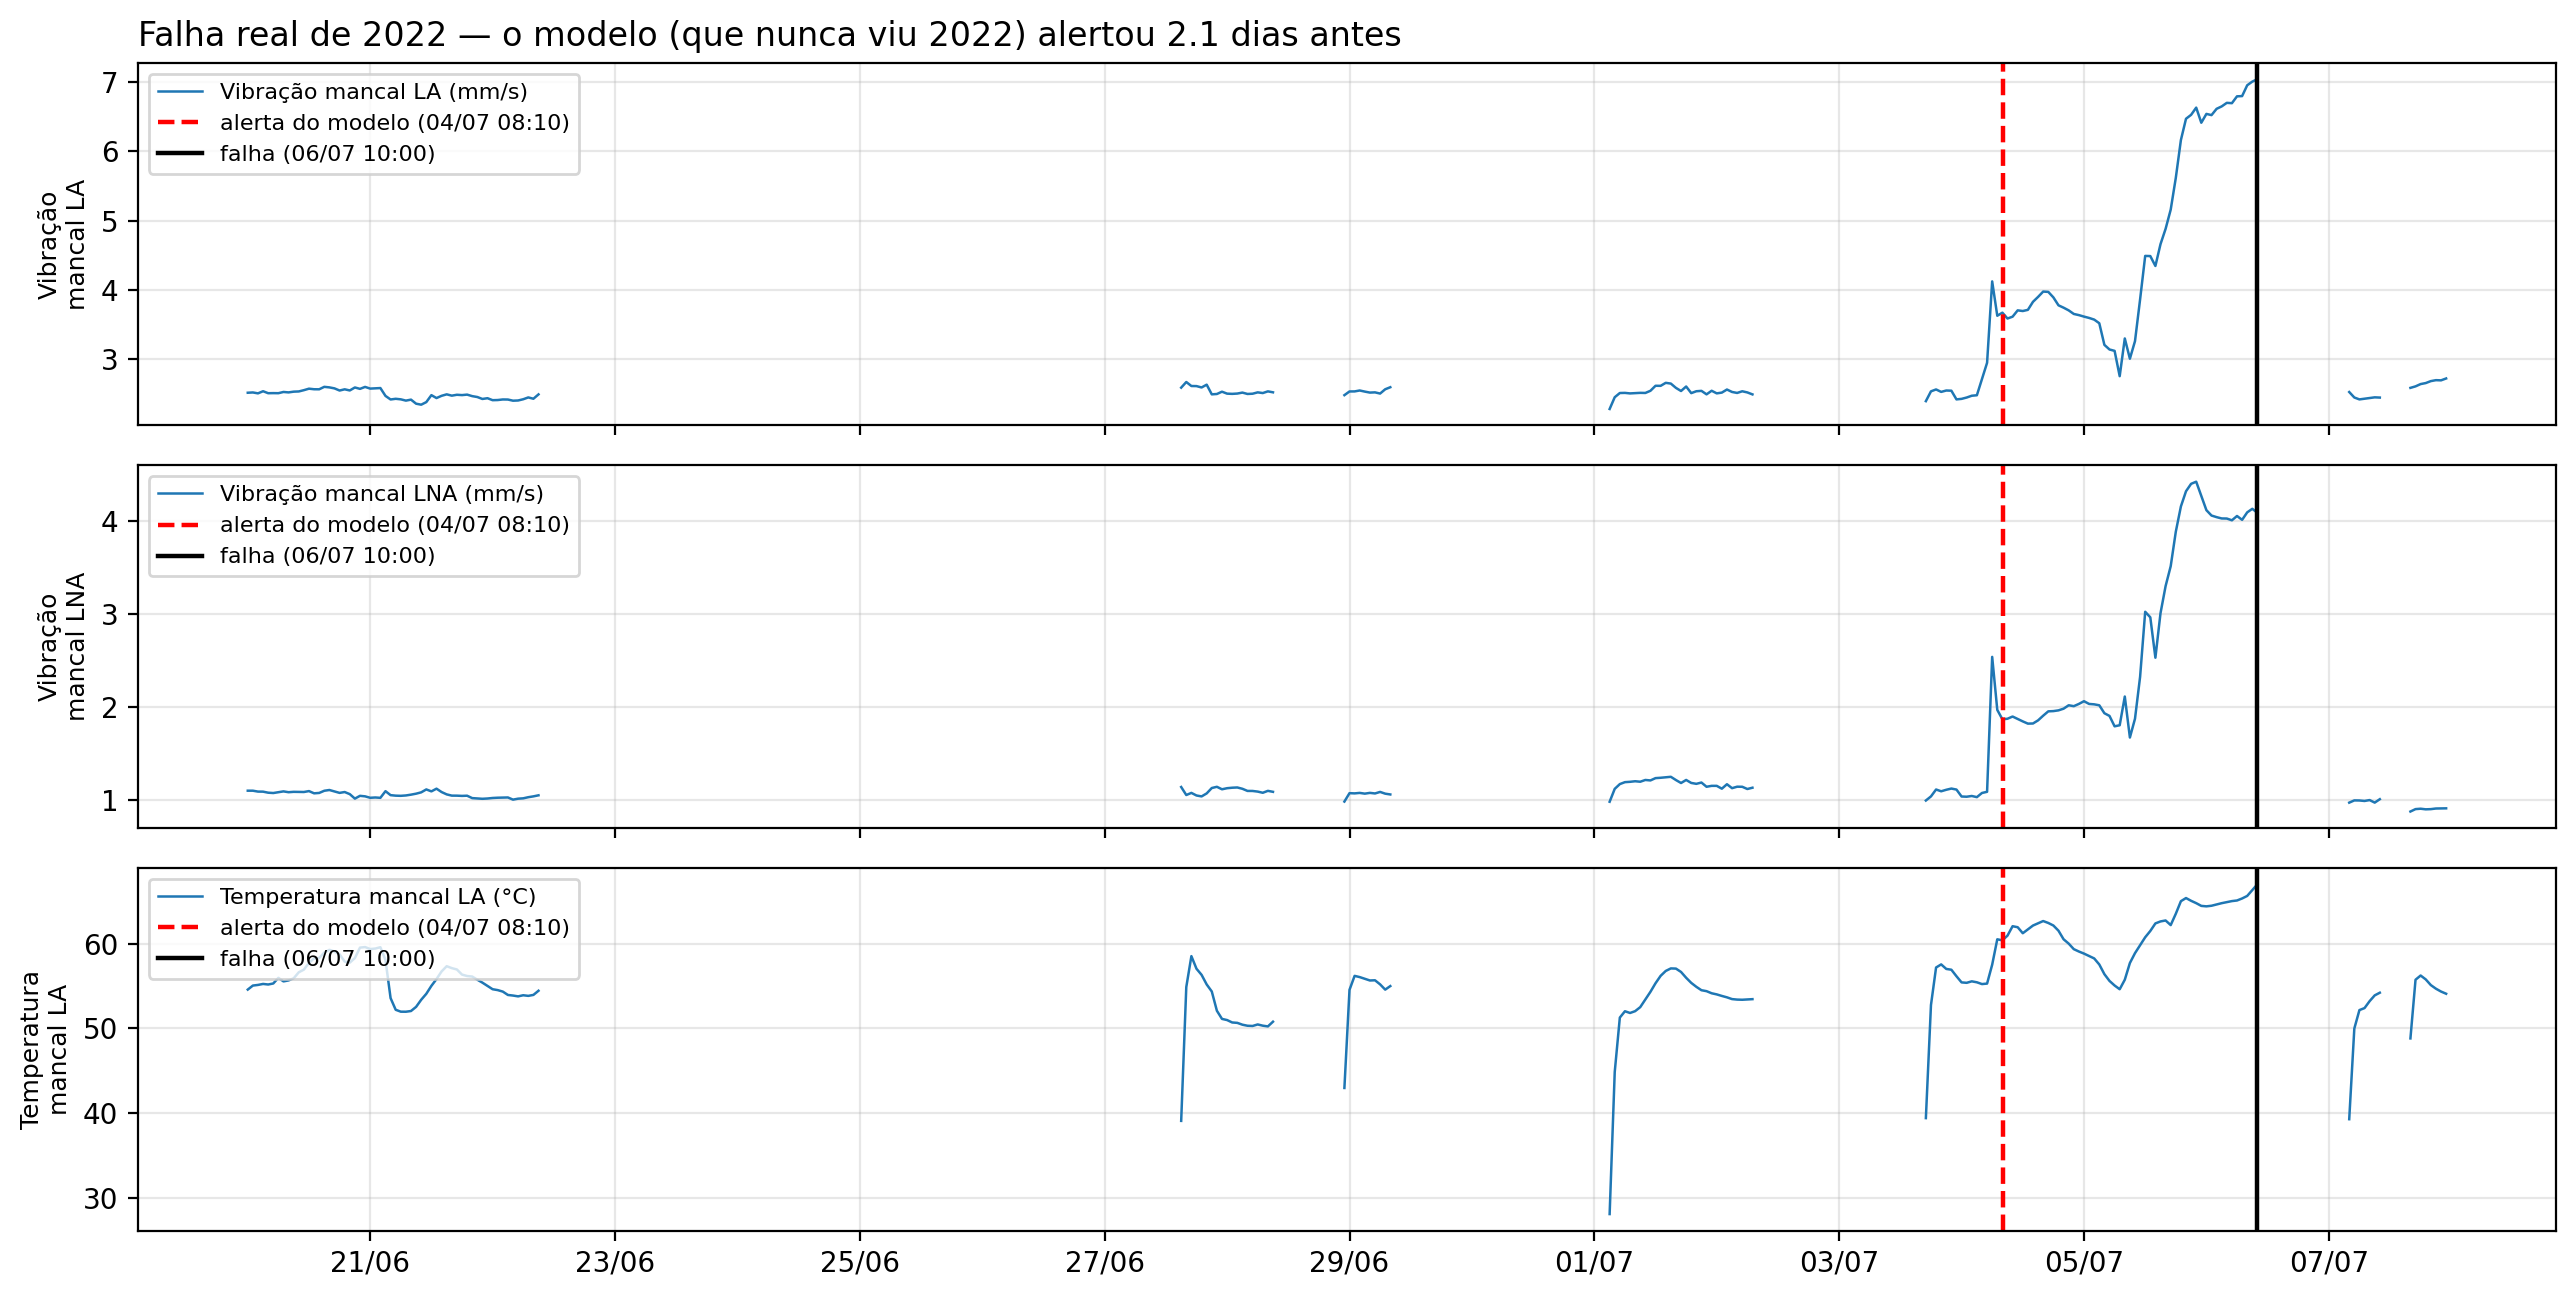

antecedência na falha real de 2022: 2.1 dias


In [4]:
FALHA = pd.Timestamp("2022-07-06 10:00")
al22 = min_duracao(alertas(raw22))
primeiro = al22[(al22.index >= "2022-06-29") & al22].index.min()
h = horaria(raw22.loc["2022-06-20":"2022-07-07"], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True)
for ax, c in zip(axes, COLS):
    ax.plot(h.index, h[c], linewidth=0.9, label=NOMES[c])
    ax.axvline(primeiro, color="red", linestyle="--", linewidth=1.6, label=f"alerta do modelo ({primeiro:%d/%m %H:%M})")
    ax.axvline(FALHA, color="black", linewidth=1.6, label="falha (06/07 10:00)")
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
antecedencia = (FALHA - primeiro).total_seconds() / 86400
axes[0].set_title(f"Falha real de 2022 — o modelo (que nunca viu 2022) alertou {antecedencia:.1f} dias antes", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()
print(f"antecedência na falha real de 2022: {antecedencia:.1f} dias")

## Slide 5 — E detecta a mesma falha, simulada em 2026

A "assinatura" medida da falha de 2022 (vibração +1,2 a +1,5 mm/s, temperatura do mancal +6,7 °C, pressões −3 %)
é somada aos dados reais de 2026 como uma rampa de 48 h. A figura mostra a simulação de 10/02/2026; a tabela, as
5 datas testadas. Em nenhuma delas o modelo alarmava antes da injeção, então o alerta vem da falha simulada.

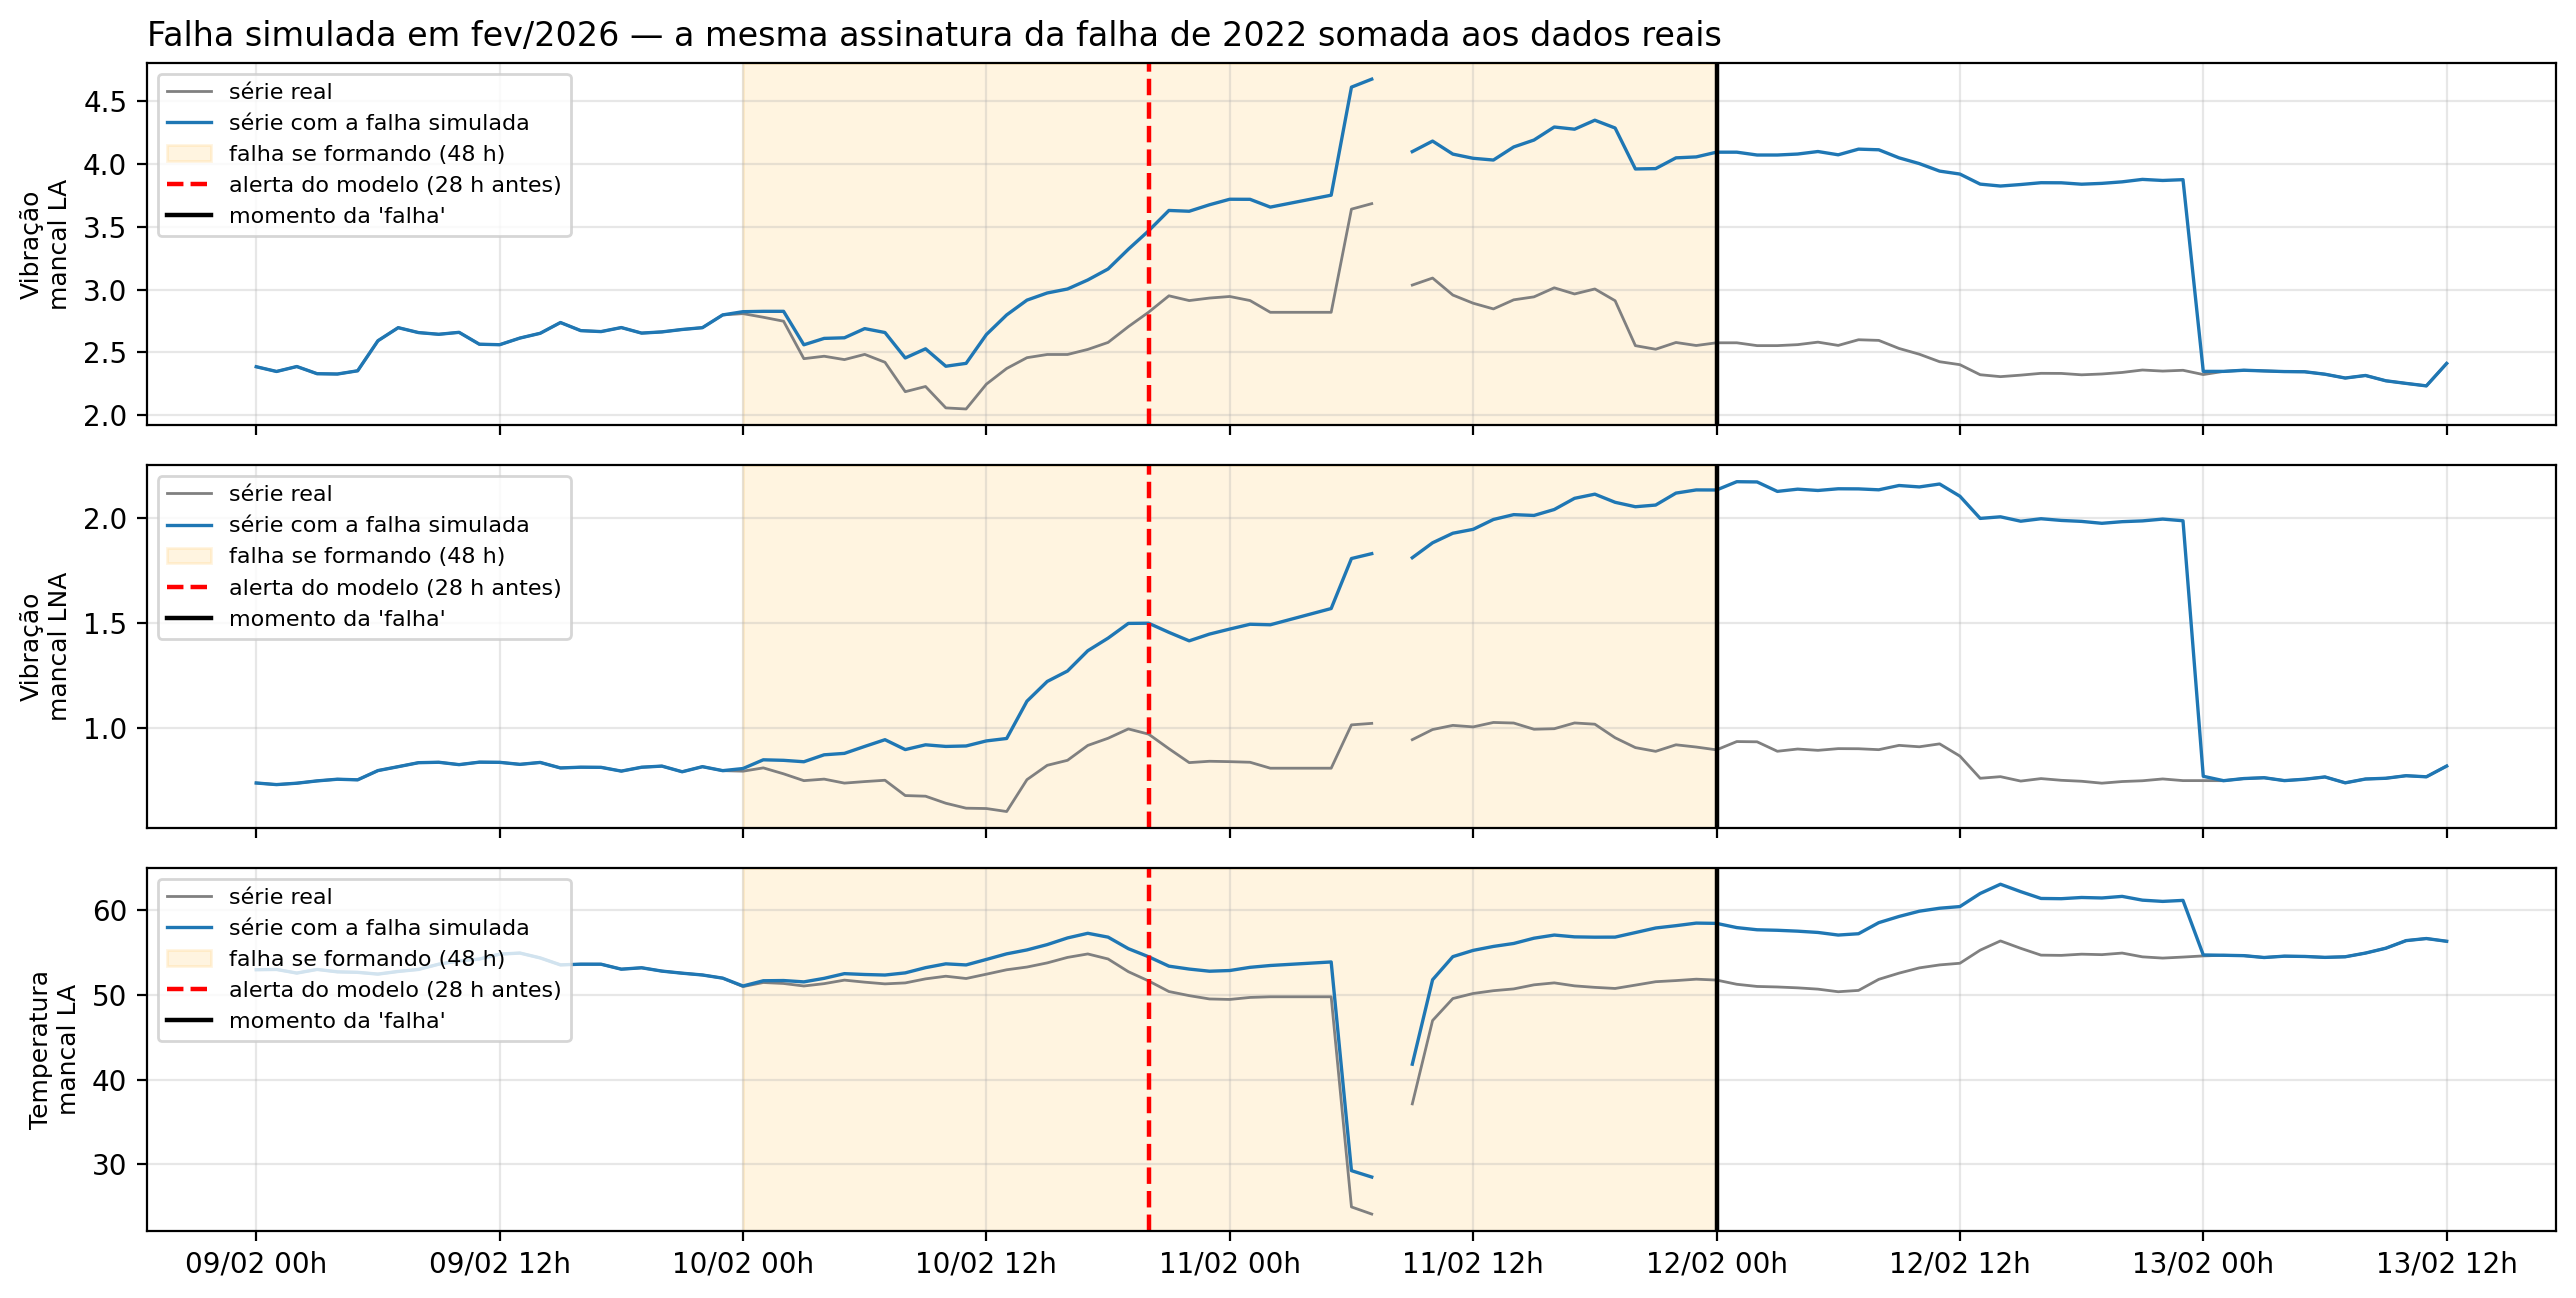

,falha simulada em,alerta,já alarmava sem a falha?
0,20/01/2026,20 h antes,não
1,10/02/2026,28 h antes,não
2,10/03/2026,14 h antes,não
3,10/06/2026,21 h antes,não
4,15/07/2026,7 h antes,não


In [5]:
sy = battery.BATTERY["B-8802B-2025"]["synthetic"]
def simular(t0):
    tf = t0 + pd.Timedelta(hours=sy["ramp_h"]); fim = tf + pd.Timedelta(hours=sy["hold_h"])
    trecho = raw.loc[t0 - pd.Timedelta(days=3): fim + pd.Timedelta(hours=12)]
    injetado = battery.inject(trecho, sy["signature"], t0, sy["ramp_h"], sy["hold_h"], 1.0)
    ai = min_duracao(alertas(injetado)); w = ai[(ai.index >= t0) & (ai.index <= fim) & ai]
    return trecho, injetado, tf, (w.index.min() if len(w) else None)

t0 = pd.Timestamp("2026-02-10")
trecho, injetado, tf, t_alerta = simular(t0)
ho = horaria(trecho.loc[t0 - pd.Timedelta(days=1):], COLS); hi_ = horaria(injetado.loc[t0 - pd.Timedelta(days=1):], COLS)
fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True)
for ax, c in zip(axes, COLS):
    ax.plot(ho.index, ho[c], color="gray", linewidth=1, label="série real")
    ax.plot(hi_.index, hi_[c], linewidth=1.2, label="série com a falha simulada")
    ax.axvspan(t0, tf, color="orange", alpha=0.12, label="falha se formando (48 h)")
    ax.axvline(t_alerta, color="red", linestyle="--", linewidth=1.6, label=f"alerta do modelo ({(tf - t_alerta).total_seconds()/3600:.0f} h antes)")
    ax.axvline(tf, color="black", linewidth=1.6, label="momento da 'falha'")
    ax.set_ylabel(rotulo(c), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("Falha simulada em fev/2026 — a mesma assinatura da falha de 2022 somada aos dados reais", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh")); plt.tight_layout(); plt.show()

linhas = []
for d in ["2026-01-20", "2026-02-10", "2026-03-10", "2026-06-10", "2026-07-15"]:
    t = pd.Timestamp(d); _, _, tf_d, ta = simular(t)
    base = min_duracao(al_todo)[(al_todo.index >= t) & (al_todo.index <= tf_d + pd.Timedelta(hours=sy["hold_h"]))]
    linhas.append({"falha simulada em": f"{t:%d/%m/%Y}",
                   "alerta": "não detecta" if ta is None else f"{(tf_d - ta).total_seconds()/3600:.0f} h antes",
                   "já alarmava sem a falha?": "sim" if base.any() else "não"})
pd.DataFrame(linhas)

## Slide 6 — Quando o normal muda, o sistema percebe

Depois do reparo de 2022 o equipamento passou a operar de outro jeito, e o modelo de 2022 passou a alarmar sem
falha nenhuma (pontos vermelhos). O monitor de mudança de conceito compara cada dia com o normal que o modelo
aprendeu e avisa quando 3 de 5 dias seguidos ficam diferentes.

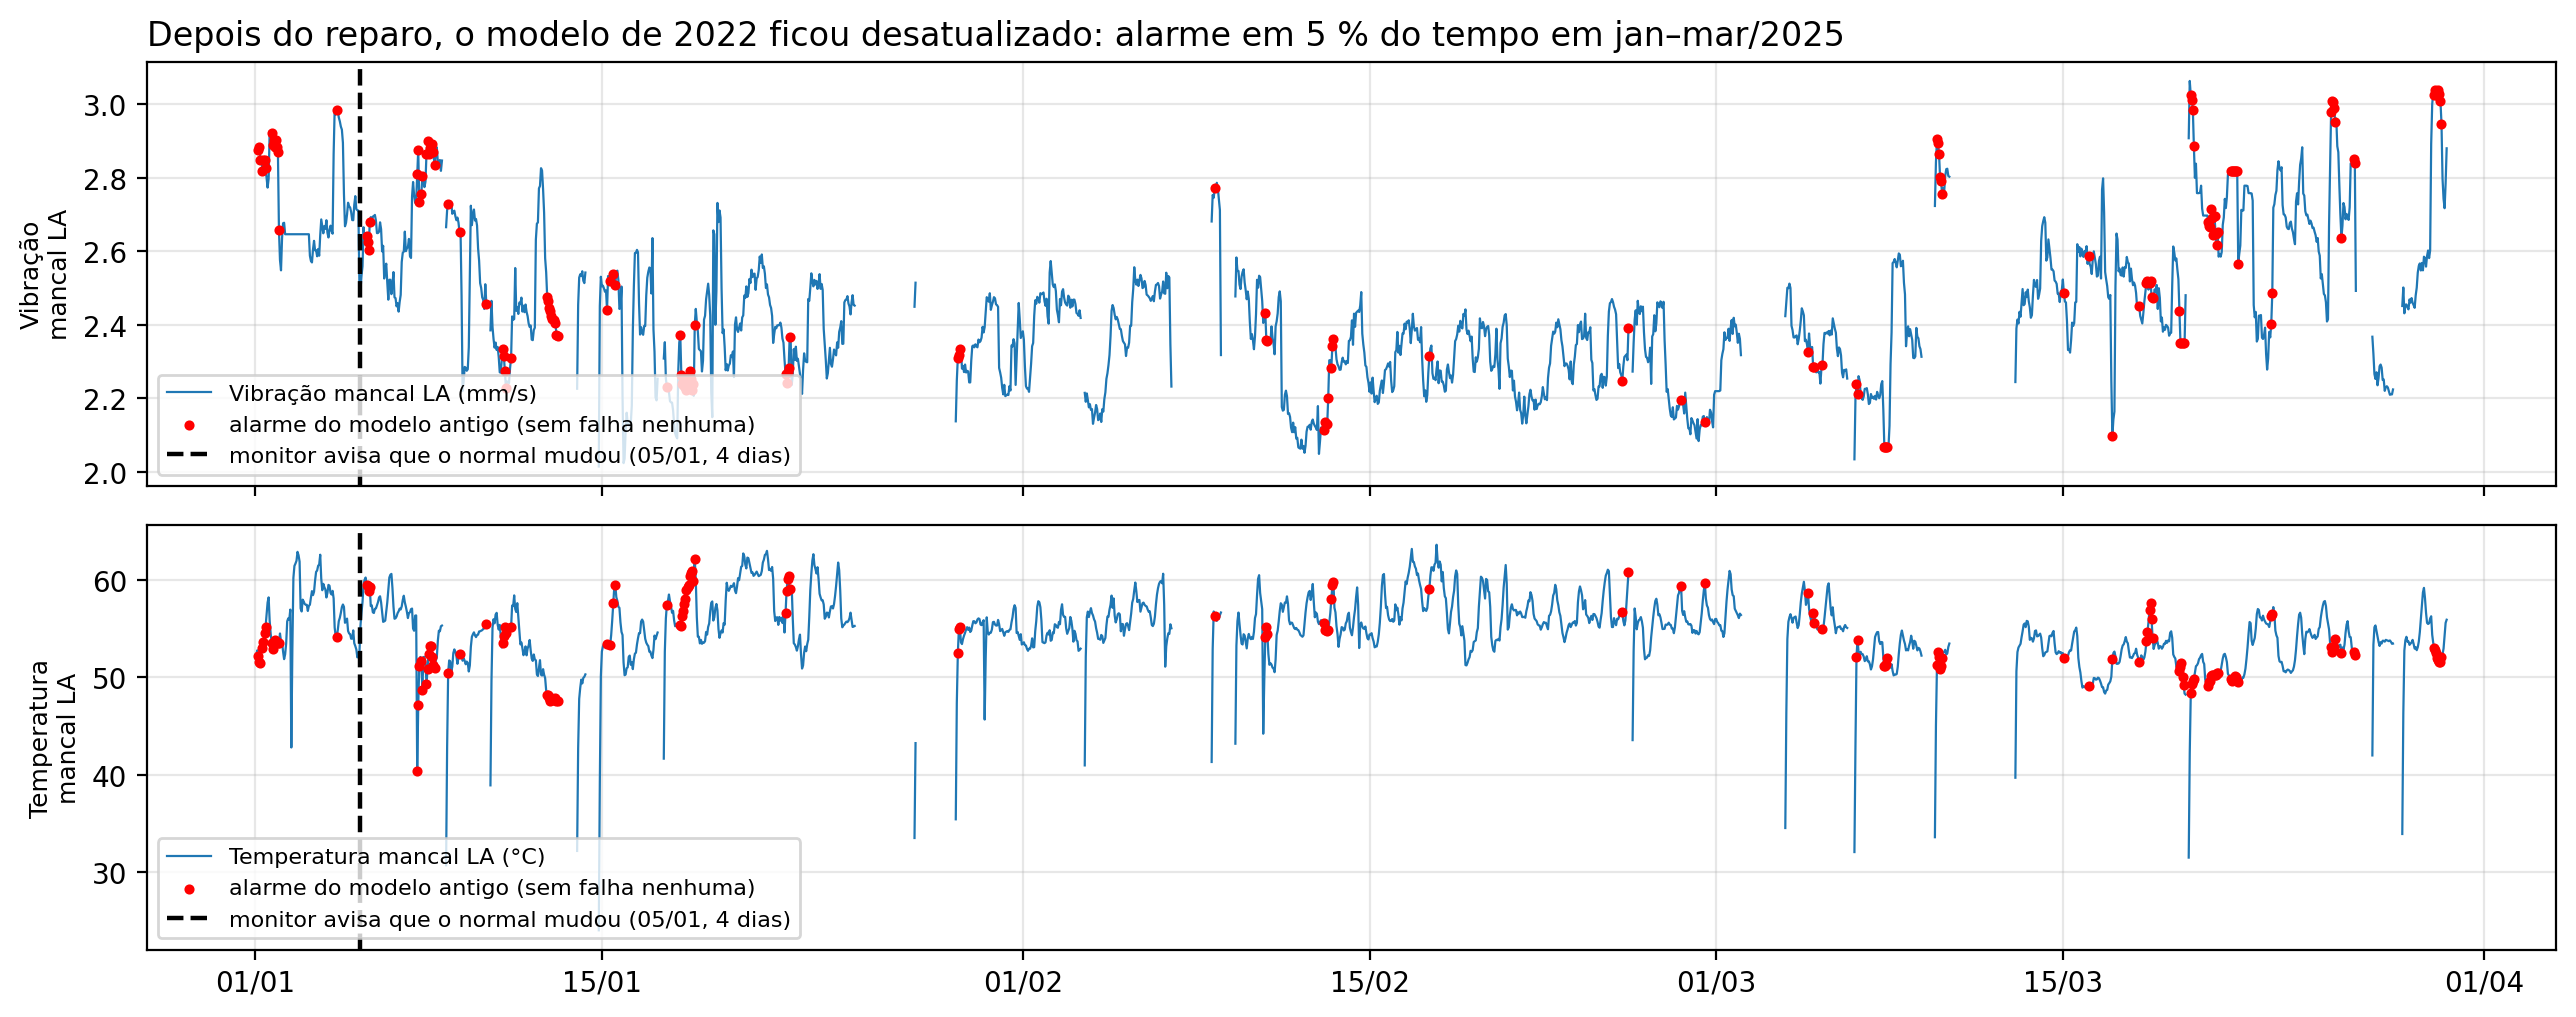

monitor avisou em 4 dias, via Vibração Bomba LA
modelo de 2022 em todo o período 2025–26: alarme em 12.2 % do tempo (sem monitor, a mudança foi percebida só 20 meses depois)


In [6]:
antigo = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)
detector = CalibratedKSDetector.from_drift_ref(B_ANTIGO / "drift_ref.json")
_, disparos = detector.scan(mon._temporal_steps(B_ANTIGO, raw)); t_aviso, sensores_aviso = disparos[0]
ini, fim = "2025-01-01", "2025-03-31"
cols6 = [("Vibração Bomba LA", "Vibração mancal LA (mm/s)"), ("Temperatura Bomba LA", "Temperatura mancal LA (°C)")]
op = raw.loc[ini:fim]; op = op[op["Pressão Descarga"] > 35]
h = op[[c for c, _ in cols6]].resample("1h").mean()
al_antigo = antigo.loc[ini:fim, "is_anomaly"]; al_h = al_antigo.resample("1h").max().fillna(False).astype(bool)
fig, axes = plt.subplots(2, 1, figsize=(13, 5.2), sharex=True)
for ax, (c, nome) in zip(axes, cols6):
    ax.plot(h.index, h[c], linewidth=0.8, label=nome)
    pts = h[c][al_h.reindex(h.index).fillna(False)]
    ax.scatter(pts.index, pts.values, s=7, color="red", zorder=3, label="alarme do modelo antigo (sem falha nenhuma)")
    ax.axvline(t_aviso, color="black", linestyle="--", linewidth=1.6,
               label=f"monitor avisa que o normal mudou ({t_aviso:%d/%m}, {(t_aviso - pd.Timestamp(ini)).days} dias)")
    ax.set_ylabel(nome.split(" (")[0].replace(" mancal", "\nmancal"), fontsize=9); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
axes[0].set_title(f"Depois do reparo, o modelo de 2022 ficou desatualizado: alarme em {100 * al_antigo.mean():.0f} % do tempo em jan–mar/2025", loc="left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()
print(f"monitor avisou em {(t_aviso - pd.Timestamp(ini)).days} dias, via {', '.join(sensores_aviso)}")
print(f"modelo de 2022 em todo o período 2025–26: alarme em {100 * antigo['is_anomaly'].mean():.1f} % do tempo "
      "(sem monitor, a mudança foi percebida só 20 meses depois)")

## Slide 7 — Quando o normal muda, como o retreino se comporta

Se o monitor avisar e a operação confirmar um normal novo, não dá para esperar 12 meses de dado para ter um modelo
novo. O teste abaixo simula isso em 2025, como se o normal tivesse mudado em jan/2025: um modelo provisório com
**1 mês** de dado, retreinado todo mês com tudo o que acumulou, até **12 meses**. Cada etapa escolheu 1 de 3
candidatos. Os modelos foram treinados no ClearML (task `retreino-acumulativo-b8802b-3c`); aqui só lemos os
resultados (`src/transpetro_modelos/drift/acumulativo.py`, detalhes em `retreino_acumulativo_explicado_B-8802B.ipynb`).

Duas perguntas por etapa:
- **Alarme sem falha:** % do tempo em alarme no mês em que aquele modelo esteve em produção.
- **Detecção:** das falhas simuladas em 5 datas de 2026, quantas o modelo detectou antes do fim da rampa.
  Datas em que o modelo já alarmava antes da injeção não contam.

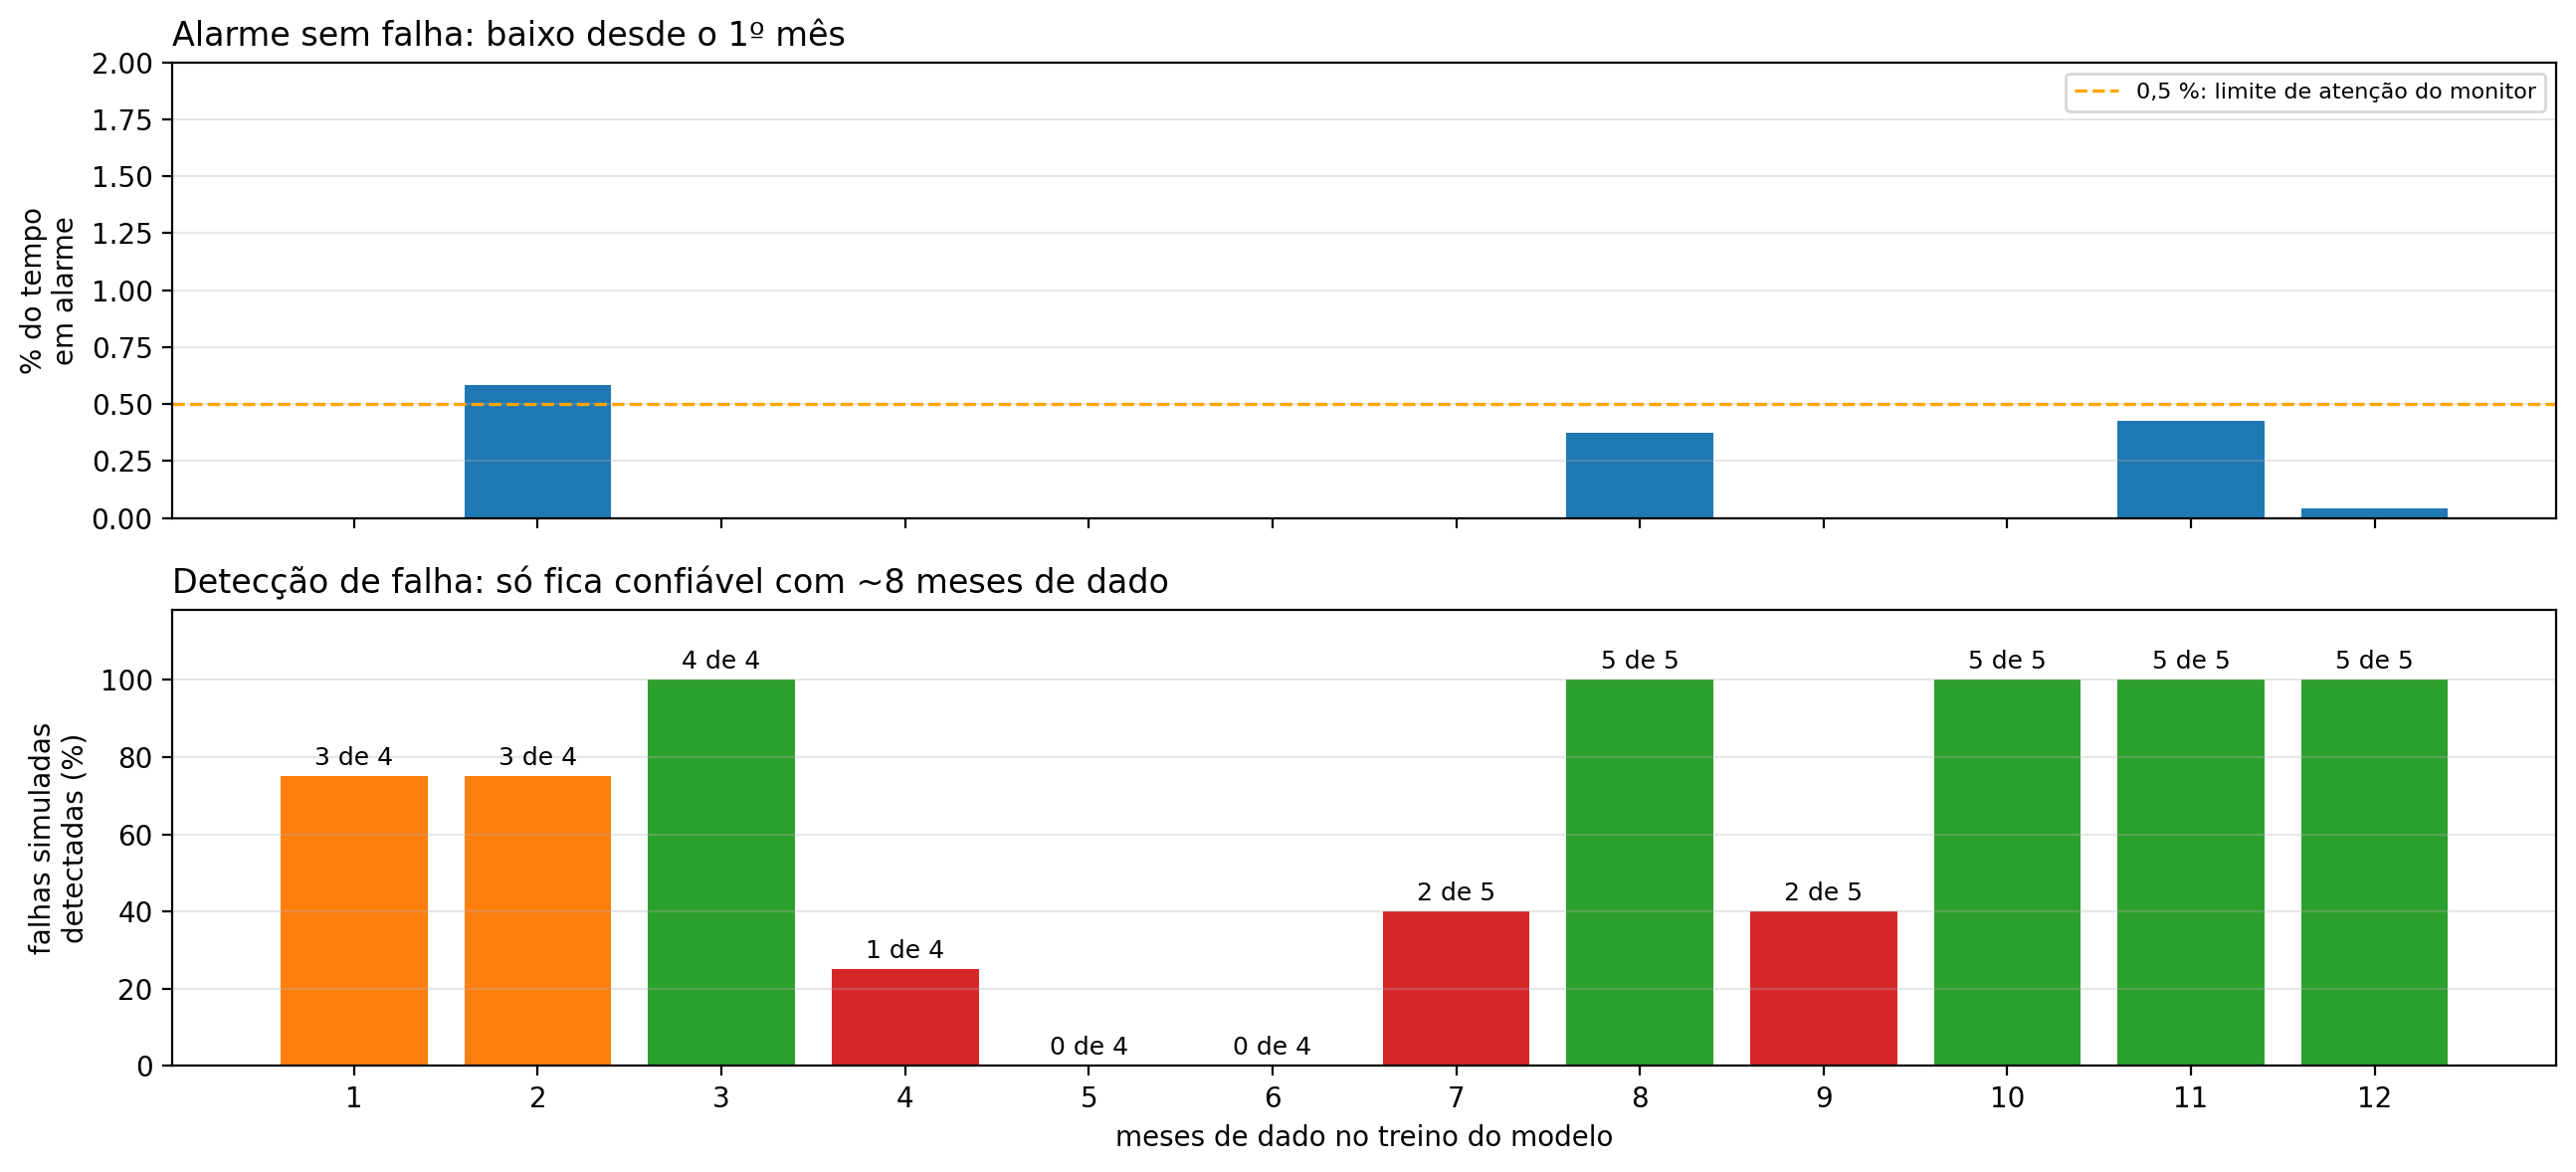

alarme sem falha, média das 12 etapas: 0.12 % (máximo 0.59 %)
detectam todas as falhas simuladas válidas: 3 meses, 8 meses, 10 meses, 11 meses, 12 meses
detectam menos da metade: 4 meses, 5 meses, 6 meses, 7 meses, 9 meses
falha real de 2022: detectada em 11 de 12 etapas, 0.6 a 2.1 dias antes


In [7]:
R = PROJECT_ROOT / "results/acumulativo_b8802b_3c"
etapas = pd.read_csv(R / "etapas.csv").set_index("etapa")
sint = pd.read_csv(R / "sintetica_varias_datas.csv").merge(pd.read_csv(R / "alarme_base_por_janela.csv"),
                                                           on=["etapa", "semente", "data"], how="left")
esc = sint[sint["escolhido"]].copy()
esc["valida"] = ~esc["alarma_sem_falha"].fillna(False).astype(bool)
esc["detecta"] = esc["valida"] & (esc["sintetica_100_h"] > 0)
det = esc.groupby("etapa").agg(validas=("valida", "sum"), detectadas=("detecta", "sum"))
det["pct"] = 100 * det["detectadas"] / det["validas"]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].bar(etapas.index, etapas["alarme_pct_vivo"])
axes[0].axhline(0.5, color="orange", linestyle="--", linewidth=1.2, label="0,5 %: limite de atenção do monitor")
axes[0].set_ylim(0, 2); axes[0].set_ylabel("% do tempo\nem alarme")
axes[0].set_title("Alarme sem falha: baixo desde o 1º mês", loc="left"); axes[0].legend(loc="upper right", fontsize=8)
cores = ["tab:green" if p == 100 else "tab:red" if p < 50 else "tab:orange" for p in det["pct"]]
axes[1].bar(det.index, det["pct"], color=cores)
for e, r in det.iterrows():
    axes[1].text(e, r["pct"] + 3, f"{r['detectadas']:.0f} de {r['validas']:.0f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 118); axes[1].set_ylabel("falhas simuladas\ndetectadas (%)")
axes[1].set_title("Detecção de falha: só fica confiável com ~8 meses de dado", loc="left")
axes[1].set_xticks(etapas.index); axes[1].set_xlabel("meses de dado no treino do modelo")
for ax in axes: ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"alarme sem falha, média das 12 etapas: {etapas['alarme_pct_vivo'].mean():.2f} % (máximo {etapas['alarme_pct_vivo'].max():.2f} %)")
print("detectam todas as falhas simuladas válidas:", ", ".join(f"{e} meses" for e in det.index[det["pct"] == 100]))
print("detectam menos da metade:", ", ".join(f"{e} meses" for e in det.index[det["pct"] < 50]))
f22 = etapas["falha_2022_dias"]
print(f"falha real de 2022: detectada em {f22.notna().sum()} de 12 etapas, "
      f"{f22.min():.1f} a {f22.max():.1f} dias antes")

**Leitura:** o modelo provisório quase não gera alarme falso desde o 1º mês, então dá para colocá-lo em
produção logo. Mas com 4 a 7 meses (e 9) ele pode ficar cego para a falha, e é o sorteio do treino que decide.
Por isso, na política, os alertas do provisório valem **com ressalva** até ~8 meses, e o modelo antigo não é
descartado antes disso.

## Slide 8 — Como vai ser a integração

O retreino **não tem data marcada**. O modelo integrado já está pronto e fica fixo; ele só é retreinado quando o
normal do equipamento muda de verdade.

| quando | o que acontece |
|---|---|
| **dia 0** | integra o modelo B-8802B-2025, já treinado com 12 meses de 2025 e testado em 2026. Não precisa esperar nada para retreinar. |
| **todo dia** | o modelo avalia os sensores; alarme de 1 hora ou mais vira alerta para a operação verificar. |
| **toda semana** | o monitor (`scripts/monitor_drift.py`) compara a semana com o normal aprendido e dá um semáforo: verde, amarelo (investigar) ou vermelho (o normal mudou). Nas **4 primeiras semanas** ele só registra, para confirmarmos que não dá aviso falso. |
| **se ficar vermelho** | a operação diz o que mudou (manutenção, regime, troca de sensor). Se for um normal novo, abre o retreino. Se for degradação, **não** retreina: é o alerta que interessa. |
| **no retreino** | 1 mês coletando o normal novo → modelo provisório → retreinado todo mês acumulando → com 12 meses fica fixo. Cada modelo novo passa pelos testes (falha de 2022 e falha simulada) e roda 4 semanas ao lado do atual antes de substituir. |
| **uma vez por ano** | mesmo tudo verde, repete os testes com o modelo em produção. Sem gatilho, não retreina. |


### As mudanças de conceito que o monitor viu, e qual regra disparou

O monitor roda toda semana sobre o que o modelo produziu e olha 4 indicadores:

| indicador | o que mede |
|---|---|
| **alarme %** | fração da semana com o modelo em alarme |
| **erro relativo** | erro mediano da semana ÷ erro médio no treino: o quanto o normal de agora está longe do normal aprendido |
| **fora da faixa %** | fração da semana em que algum sensor ficou fora da faixa vista no treino (o modelo deixa de enxergar esse sensor) |
| **KS diário** | compara, sensor a sensor, a distribuição de cada dia com a do treino; dispara quando 3 de 5 dias seguidos ficam diferentes |

Cada indicador vira um semáforo pela regra **k das últimas n semanas** (tabela abaixo, lida do próprio monitor,
`src/transpetro_modelos/drift/monitor.py`). Um disparo do KS nas últimas 4 semanas deixa o semáforo pelo menos
amarelo. **Amarelo** = investigar com a operação, não retreinar. **Vermelho** = o normal mudou; confirmado com a
operação, abre o retreino.

Rodamos o monitor nos dois casos que temos em 2025–26:
- **modelo antigo** (treinado em 2022) lendo 2025–26: é a mudança de conceito real, depois do reparo;
- **modelo atual** (treinado em 2025) lendo 2025–26: é o que vai para produção.

In [8]:
NOMES_IND = {"alarme_pct": "alarme %", "erro_p50_rel": "erro relativo", "fora_clip_pct": "fora da faixa %"}
regras = pd.DataFrame([{"semáforo": nivel, "indicador": NOMES_IND[m], "passa de": thr, "em": f"{k} das últimas {n} semanas"}
                       for nivel, rr in mon.RULES.items() for m, (thr, k, n) in rr.items()])
regras

,semáforo,indicador,passa de,em
0,amarelo,alarme %,0.5,2 das últimas 4 semanas
1,amarelo,erro relativo,2.0,6 das últimas 8 semanas
2,amarelo,fora da faixa %,10.0,2 das últimas 4 semanas
3,vermelho,alarme %,2.0,4 das últimas 6 semanas
4,vermelho,erro relativo,2.5,6 das últimas 8 semanas
5,vermelho,fora da faixa %,25.0,4 das últimas 6 semanas


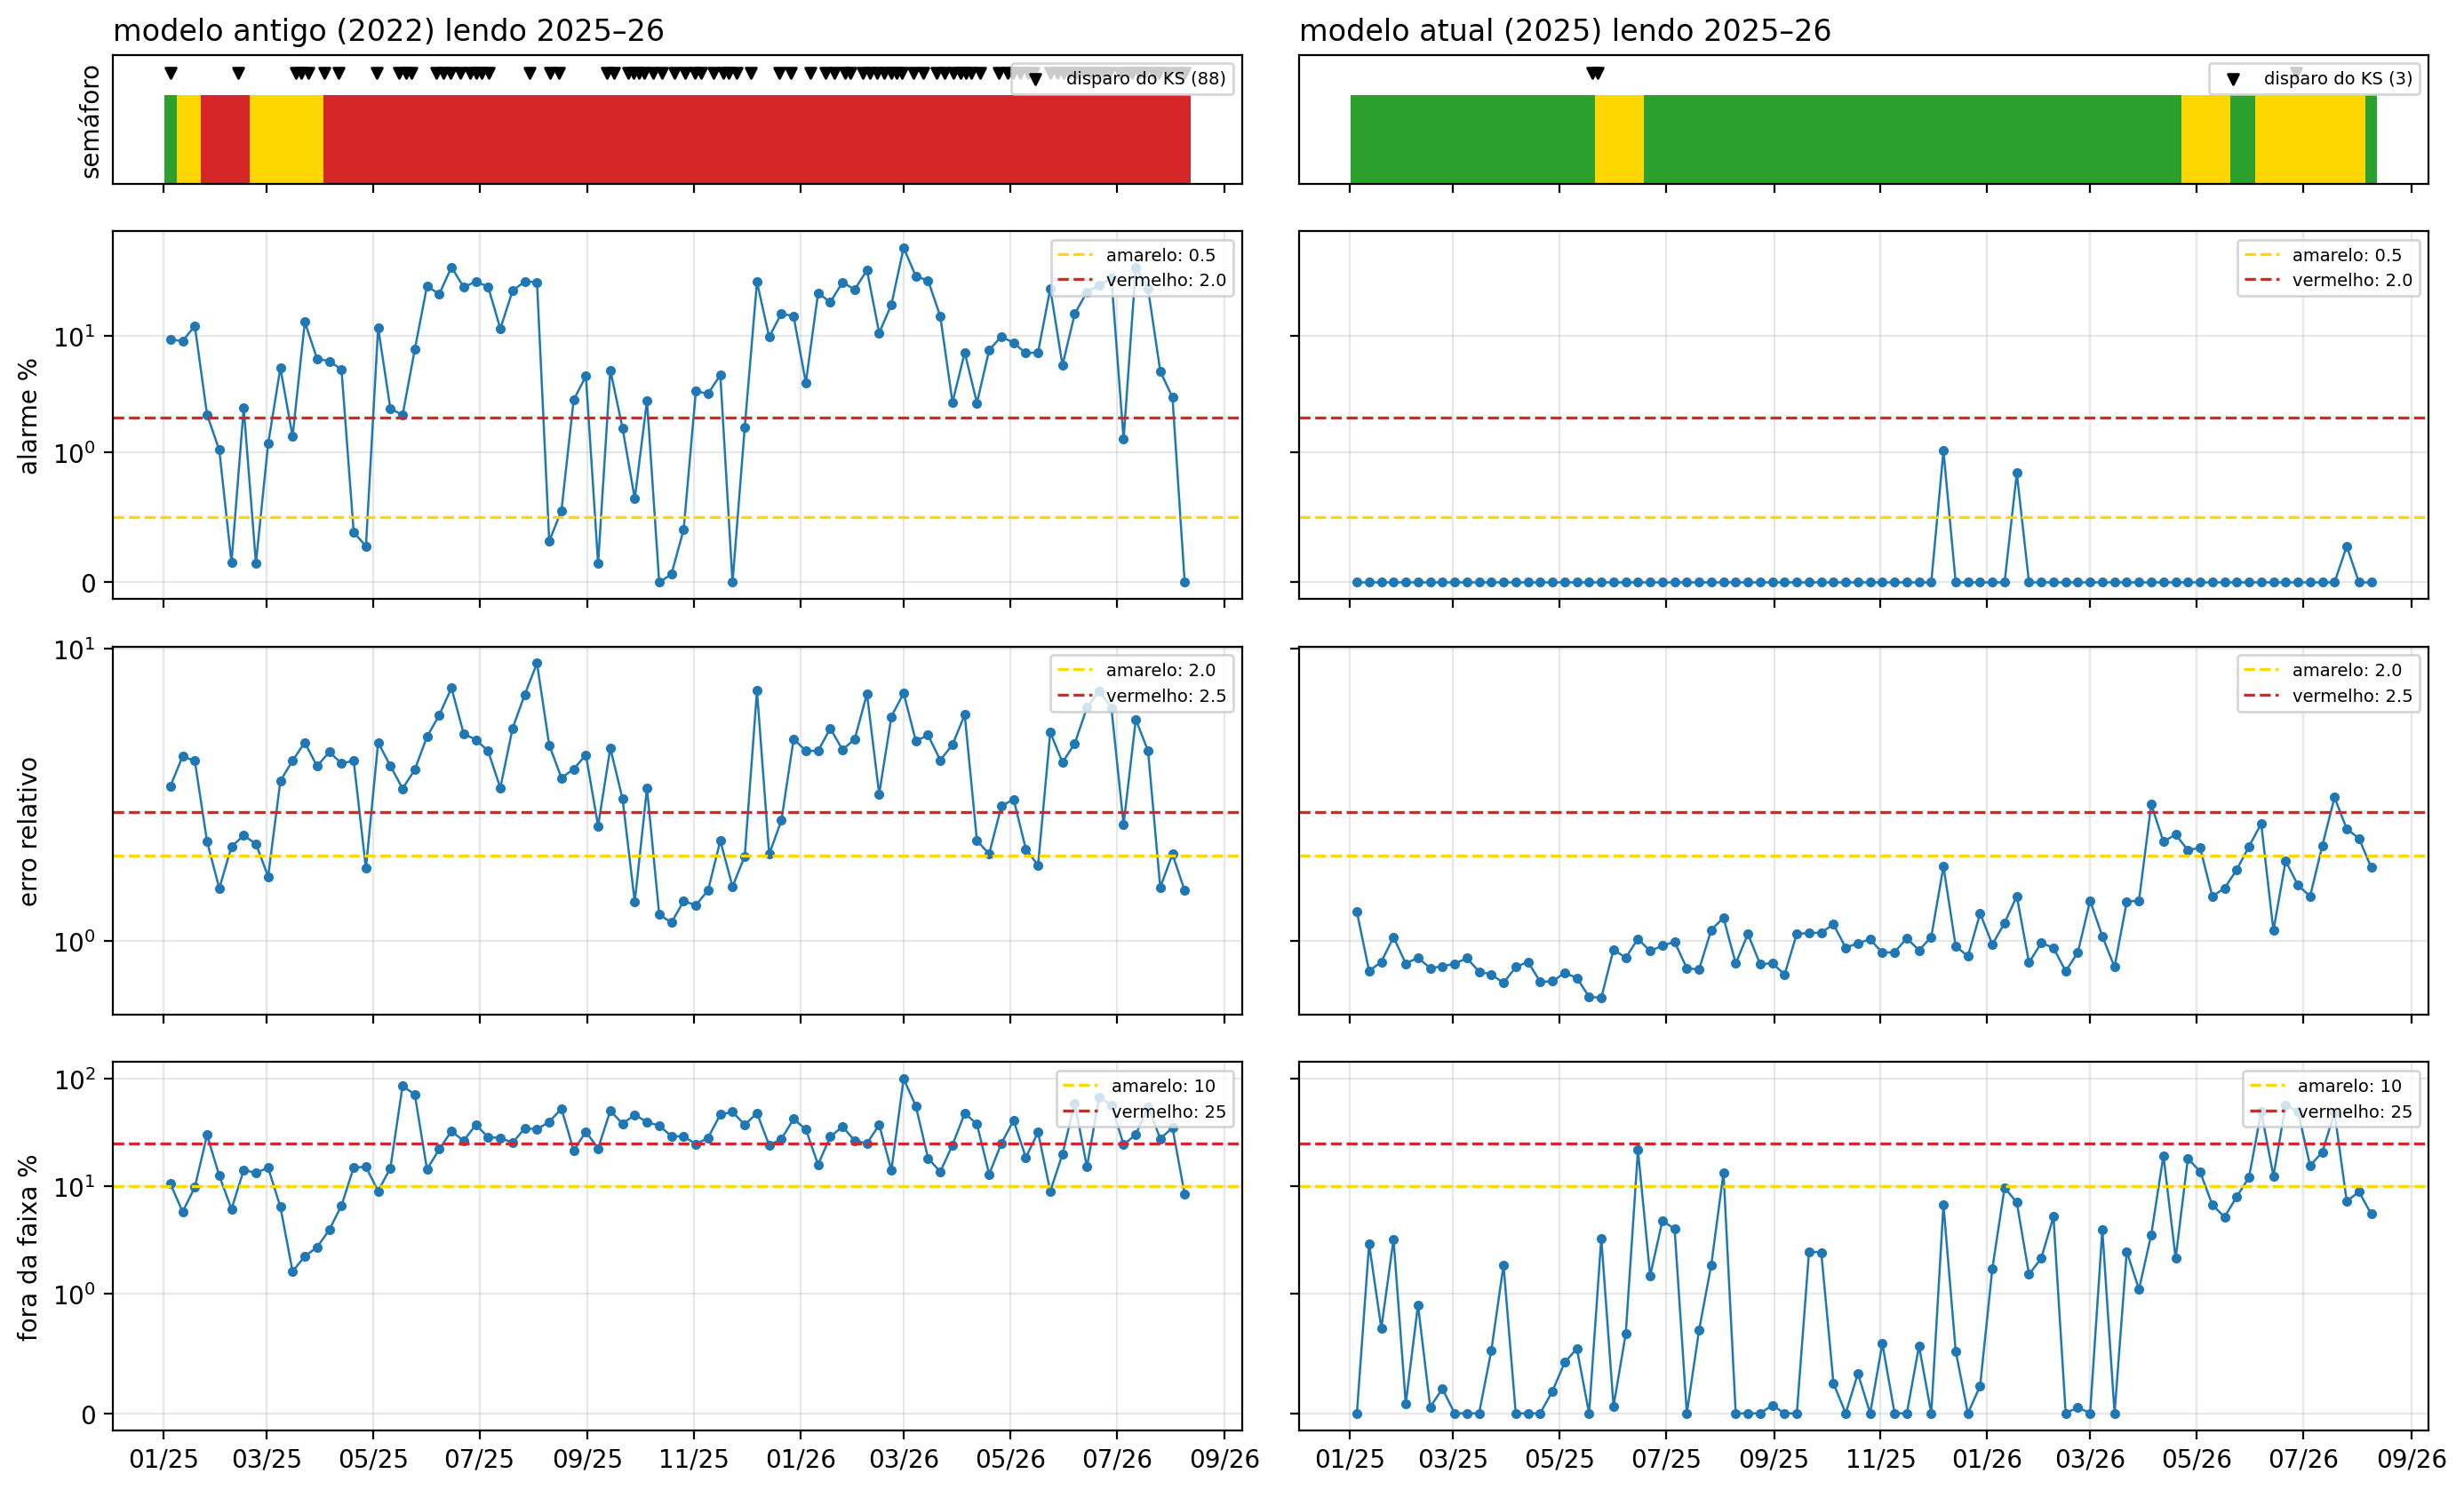

In [9]:
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"

def semaforo(bundle, inf):
    """Semana a semana: indicadores, semáforo e as regras que dispararam (igual ao scripts/monitor_drift.py)."""
    mu = json.loads((bundle / "alarm.json").read_text())["threshold_calibration"]["mean_normal"]
    w = mon.weekly_table(inf, mu).join(mon.clip_saturation(DADOS, bundle, "W"))
    wv = w[w["valida"]].copy()
    ks = mon.ks_daily_fires(DADOS, bundle)
    status, motivo = [], []
    for i in range(len(wv)):
        st, razoes = mon.status_at(wv.iloc[: i + 1])
        t = wv.index[i]
        ks_rec = [(tk, s) for tk, s in ks if t - pd.Timedelta(days=28) <= tk <= t]
        if ks_rec and st == "verde": st = "amarelo"
        nomes = sorted({NOMES_IND[r.split(" >")[0]] for r in razoes})
        if ks_rec: nomes.append("KS (" + ", ".join(sorted({x for _, s in ks_rec for x in s})) + ")")
        status.append(st); motivo.append(", ".join(nomes))
    wv["semáforo"], wv["regra que disparou"] = status, motivo
    return wv, ks

inf_antigo = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv",
                         index_col=0, parse_dates=True)
inf_atual = si.prever(B, modelo, si.preprocessar(B, raw))           # o CSV que o deploy grava
casos = {"modelo antigo (2022) lendo 2025–26": semaforo(B_ANTIGO, inf_antigo),
         "modelo atual (2025) lendo 2025–26": semaforo(B, inf_atual)}

COR = {"verde": "tab:green", "amarelo": "gold", "vermelho": "tab:red"}
LIM = {"alarme_pct": (0.5, 2.0), "erro_p50_rel": (2.0, 2.5), "fora_clip_pct": (10, 25)}
fig, axes = plt.subplots(4, 2, figsize=(14, 8.5), sharex=True, sharey="row",
                         gridspec_kw={"height_ratios": [0.35, 1, 1, 1]})
for j, (nome, (wv, ks)) in enumerate(casos.items()):
    ax = axes[0, j]
    ax.bar(wv.index, 1, width=7, color=[COR[s] for s in wv["semáforo"]])
    ax.scatter([t for t, _ in ks], [1.25] * len(ks), marker="v", color="black", s=18, clip_on=False,
               label=f"disparo do KS ({len(ks)})")
    ax.set_ylim(0, 1.45); ax.set_yticks([]); ax.set_title(nome, loc="left"); ax.legend(loc="upper right", fontsize=7)
    for i, (m, (am, vm)) in enumerate(LIM.items(), start=1):
        ax = axes[i, j]
        ax.plot(wv.index, wv[m], marker=".", linewidth=0.9)
        ax.axhline(am, color="gold", linestyle="--", linewidth=1.2, label=f"amarelo: {am}")
        ax.axhline(vm, color="tab:red", linestyle="--", linewidth=1.2, label=f"vermelho: {vm}")
        ax.set_yscale("symlog", linthresh=1 if m != "erro_p50_rel" else 3); ax.grid(alpha=0.3)
        if j == 0: ax.set_ylabel(NOMES_IND[m])
        ax.legend(loc="upper right", fontsize=7)
axes[0, 0].set_ylabel("semáforo")
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
plt.tight_layout(); plt.show()

In [10]:
linhas = []
for nome, (wv, ks) in casos.items():
    tl = wv["semáforo"]
    am, vm = tl[tl != "verde"], tl[tl == "vermelho"]
    linhas.append({"caso": nome,
                   "verde / amarelo / vermelho (semanas)": " / ".join(str(int((tl == k).sum())) for k in ("verde", "amarelo", "vermelho")),
                   "1º amarelo": f"{am.index.min():%d/%m/%Y}" if len(am) else "—",
                   "1º vermelho": f"{vm.index.min():%d/%m/%Y}" if len(vm) else "—",
                   "regra que disparou (semanas)": "; ".join(f"{r}: {n}" for r, n in wv.loc[tl != "verde", "regra que disparou"].value_counts().head(3).items()),
                   "1º disparo do KS": f"{ks[0][0]:%d/%m/%Y} ({', '.join(ks[0][1])})" if ks else "—",
                   "semáforo na última semana": tl.iloc[-1]})
pd.DataFrame(linhas).set_index("caso").T

caso,modelo antigo (2022) lendo 2025–26,modelo atual (2025) lendo 2025–26
verde / amarelo / vermelho (semanas),1 / 8 / 75,67 / 17 / 0
1º amarelo,12/01/2025,25/05/2025
1º vermelho,26/01/2025,—
regra que disparou (semanas),"alarme %, erro relativo, fora da faixa %, KS (...",fora da faixa %: 9; KS (Vibração Bomba LNA): 4...
1º disparo do KS,05/01/2025 (Vibração Bomba LA),19/05/2025 (Vibração Bomba LNA)
semáforo na última semana,vermelho,verde


In [11]:
wv_atual, ks_atual = casos["modelo atual (2025) lendo 2025–26"]
print("modelo atual — semanas não verdes:")
cols_sem = ["alarme_pct", "erro_p50_rel", "fora_clip_pct", "fora_clip_sensor", "semáforo", "regra que disparou"]
display(wv_atual.loc[wv_atual["semáforo"] != "verde", cols_sem].round(2))
print("disparos do KS com o modelo atual:", "; ".join(f"{t:%d/%m/%Y} via {', '.join(s)}" for t, s in ks_atual))

# o disparo de maio/2025: leitura da vibração LNA parada no mesmo valor o dia inteiro
op = mon._temporal_steps(B, raw)["Vibração Bomba LNA"]
dia = op.groupby(pd.to_datetime(op.index.date)).agg(["std", "mean", "size"])
travado = dia[(dia["std"] == 0) & (dia["size"] >= 48)]
grupos = (pd.Series(travado.index).diff() > pd.Timedelta(days=3)).cumsum().values
print("\nvibração LNA travada (mesmo valor o dia todo):")
for _, g in travado.groupby(grupos):
    ini, fim = pd.Timestamp(g.index.min()), pd.Timestamp(g.index.max())
    pegou = any(ini - pd.Timedelta(days=1) <= t <= fim + pd.Timedelta(days=5) for t, _ in ks_atual)
    print(f"  {ini:%d/%m/%Y} a {fim:%d/%m/%Y}: {len(g)} dias em {g['mean'].iloc[0]:.3f} mm/s → KS {'disparou' if pegou else 'NÃO disparou'}")
ref = json.loads((B / "drift_ref.json").read_text())
print("limite do KS por sensor (D máximo diário na referência de 2025; o máximo possível é 1):",
      {c: v["d_crit"] for c, v in ref["sensors"].items()})

modelo atual — semanas não verdes:


,alarme_pct,erro_p50_rel,fora_clip_pct,fora_clip_sensor,semáforo,regra que disparou
datetime,,,,,,
2025-05-25,0.00,0.34,3.29,Pressão Descarga,amarelo,KS (Vibração Bomba LNA)
2025-06-01,0.00,0.90,0.06,Temperatura Bomba LA,amarelo,KS (Vibração Bomba LNA)
2025-06-08,0.00,0.80,0.66,Pressão Descarga,amarelo,KS (Vibração Bomba LNA)
2025-06-15,0.00,1.02,21.70,Temperatura Bomba LA,amarelo,KS (Vibração Bomba LNA)
2026-04-26,0.00,2.06,18.21,Temperatura Bomba LA,amarelo,fora da faixa %
2026-05-03,0.00,2.09,13.64,Temperatura Bomba LA,amarelo,fora da faixa %
2026-05-10,0.00,1.52,6.72,Temperatura Bomba LA,amarelo,fora da faixa %
2026-05-17,0.00,1.62,5.18,Temperatura Bomba LA,amarelo,fora da faixa %
2026-06-07,0.00,2.37,49.50,Temperatura Bomba LA,amarelo,fora da faixa %


disparos do KS com o modelo atual: 19/05/2025 via Vibração Bomba LNA; 22/05/2025 via Vibração Bomba LNA; 27/06/2026 via Temperatura Bomba LA



vibração LNA travada (mesmo valor o dia todo):
  15/05/2025 a 22/05/2025: 8 dias em 0.015 mm/s → KS disparou
  23/02/2026 a 03/03/2026: 7 dias em 0.726 mm/s → KS NÃO disparou
  09/07/2026 a 09/07/2026: 1 dias em 0.970 mm/s → KS NÃO disparou
limite do KS por sensor (D máximo diário na referência de 2025; o máximo possível é 1): {'Pressão Sucção': 0.98, 'Pressão Descarga': 0.9606, 'Vibração Bomba LA': 0.9746, 'Vibração Bomba LNA': 0.975, 'Temperatura Bomba LA': 0.9824}


**Leitura.**
- **Modelo antigo em 2025: mudança de conceito.** O semáforo vai a vermelho em poucas semanas pelo **alarme %**
  (o modelo passa a alarmar sem falha) e pelo **erro relativo**, e o KS dispara nos primeiros dias. É o caso em
  que a política manda confirmar com a operação e retreinar, e foi o que gerou o modelo atual.
- **Modelo atual em maio–junho/2025: sensor travado.** As 4 semanas amarelas de 2025 vêm do KS pela vibração
  LNA, que ficou parada em 0,015 mm/s por vários dias (leitura constante). Não é mudança de conceito, é problema
  de sensor, e o amarelo está certo: é o tipo de coisa que a operação precisa saber.
- **Modelo atual em 2026: mudança parcial, em um sensor.** Nenhuma semana vermelha. Desde 26/04/2026 há semanas
  amarelas pela regra **fora da faixa %**, sempre pela temperatura do mancal LA (mais fria que em 2025), e o KS
  disparou em 27/06/2026 pelo mesmo sensor. O alarme % continua perto de zero. Pela política é **investigar, não
  retreinar**: perguntar à operação por que o mancal LA está mais frio desde abril.

**Um ponto a melhorar no KS do modelo atual.** O limite de cada sensor é o maior D diário visto na referência
(2025 inteiro), e ficou entre 0,96 e 0,98, perto do máximo possível (1). Duas razões: a referência inclui os dias
do sensor travado, e um único dia de operação ocupa uma faixa estreita comparado com o ano todo. Com um limite
tão alto o KS só pega mudanças extremas. A prova está na célula acima: a vibração LNA ficou travada de novo em
fev–mar/2026, agora em 0,726 mm/s, um valor no meio da faixa normal, e o KS não disparou. Recalibrar a referência sem os dias do sensor travado é
um ajuste simples (`scripts/monitor_drift.py --make-drift-ref`), a avaliar.

Os passos completos estão em `docs/politica_retreino.md`.

### O detector de mudança de conceito (KS) ao longo de 2025–26

A **regra de 1 hora vale para os alertas do modelo** (anomalia nos sensores). O detector de mudança de conceito
tem a regra dele: compara a distribuição de cada sensor numa janela (hoje, 1 dia) com a do período de
calibração, e só dispara quando **3 das últimas 5 janelas** passam do limite. O limite de cada sensor é o maior
valor visto dentro do próprio período de calibração, então esse período praticamente não passa do limite.

**Com que dado ele é calibrado:** com o mesmo período em que o modelo foi treinado. O modelo atual foi treinado
com 2025, então o KS dele é calibrado com 2025. O modelo antigo, com mai–jun/2022. A cada retreino o KS é
recalibrado junto (`scripts/monitor_drift.py --make-drift-ref`), com o período do treino novo.

A figura mostra o D de cada janela dividido pelo limite do sensor (acima de 1 = passou do limite):
1. modelo antigo lendo 2025–26, com a calibração de hoje: a mudança de conceito real;
2. modelo atual, com a calibração de hoje (janela de 1 dia, 2025 inteiro);
3. modelo atual, com uma calibração **proposta**: janela de 3 dias e referência de 2025 sem os dias em que
   algum sensor ficou travado.

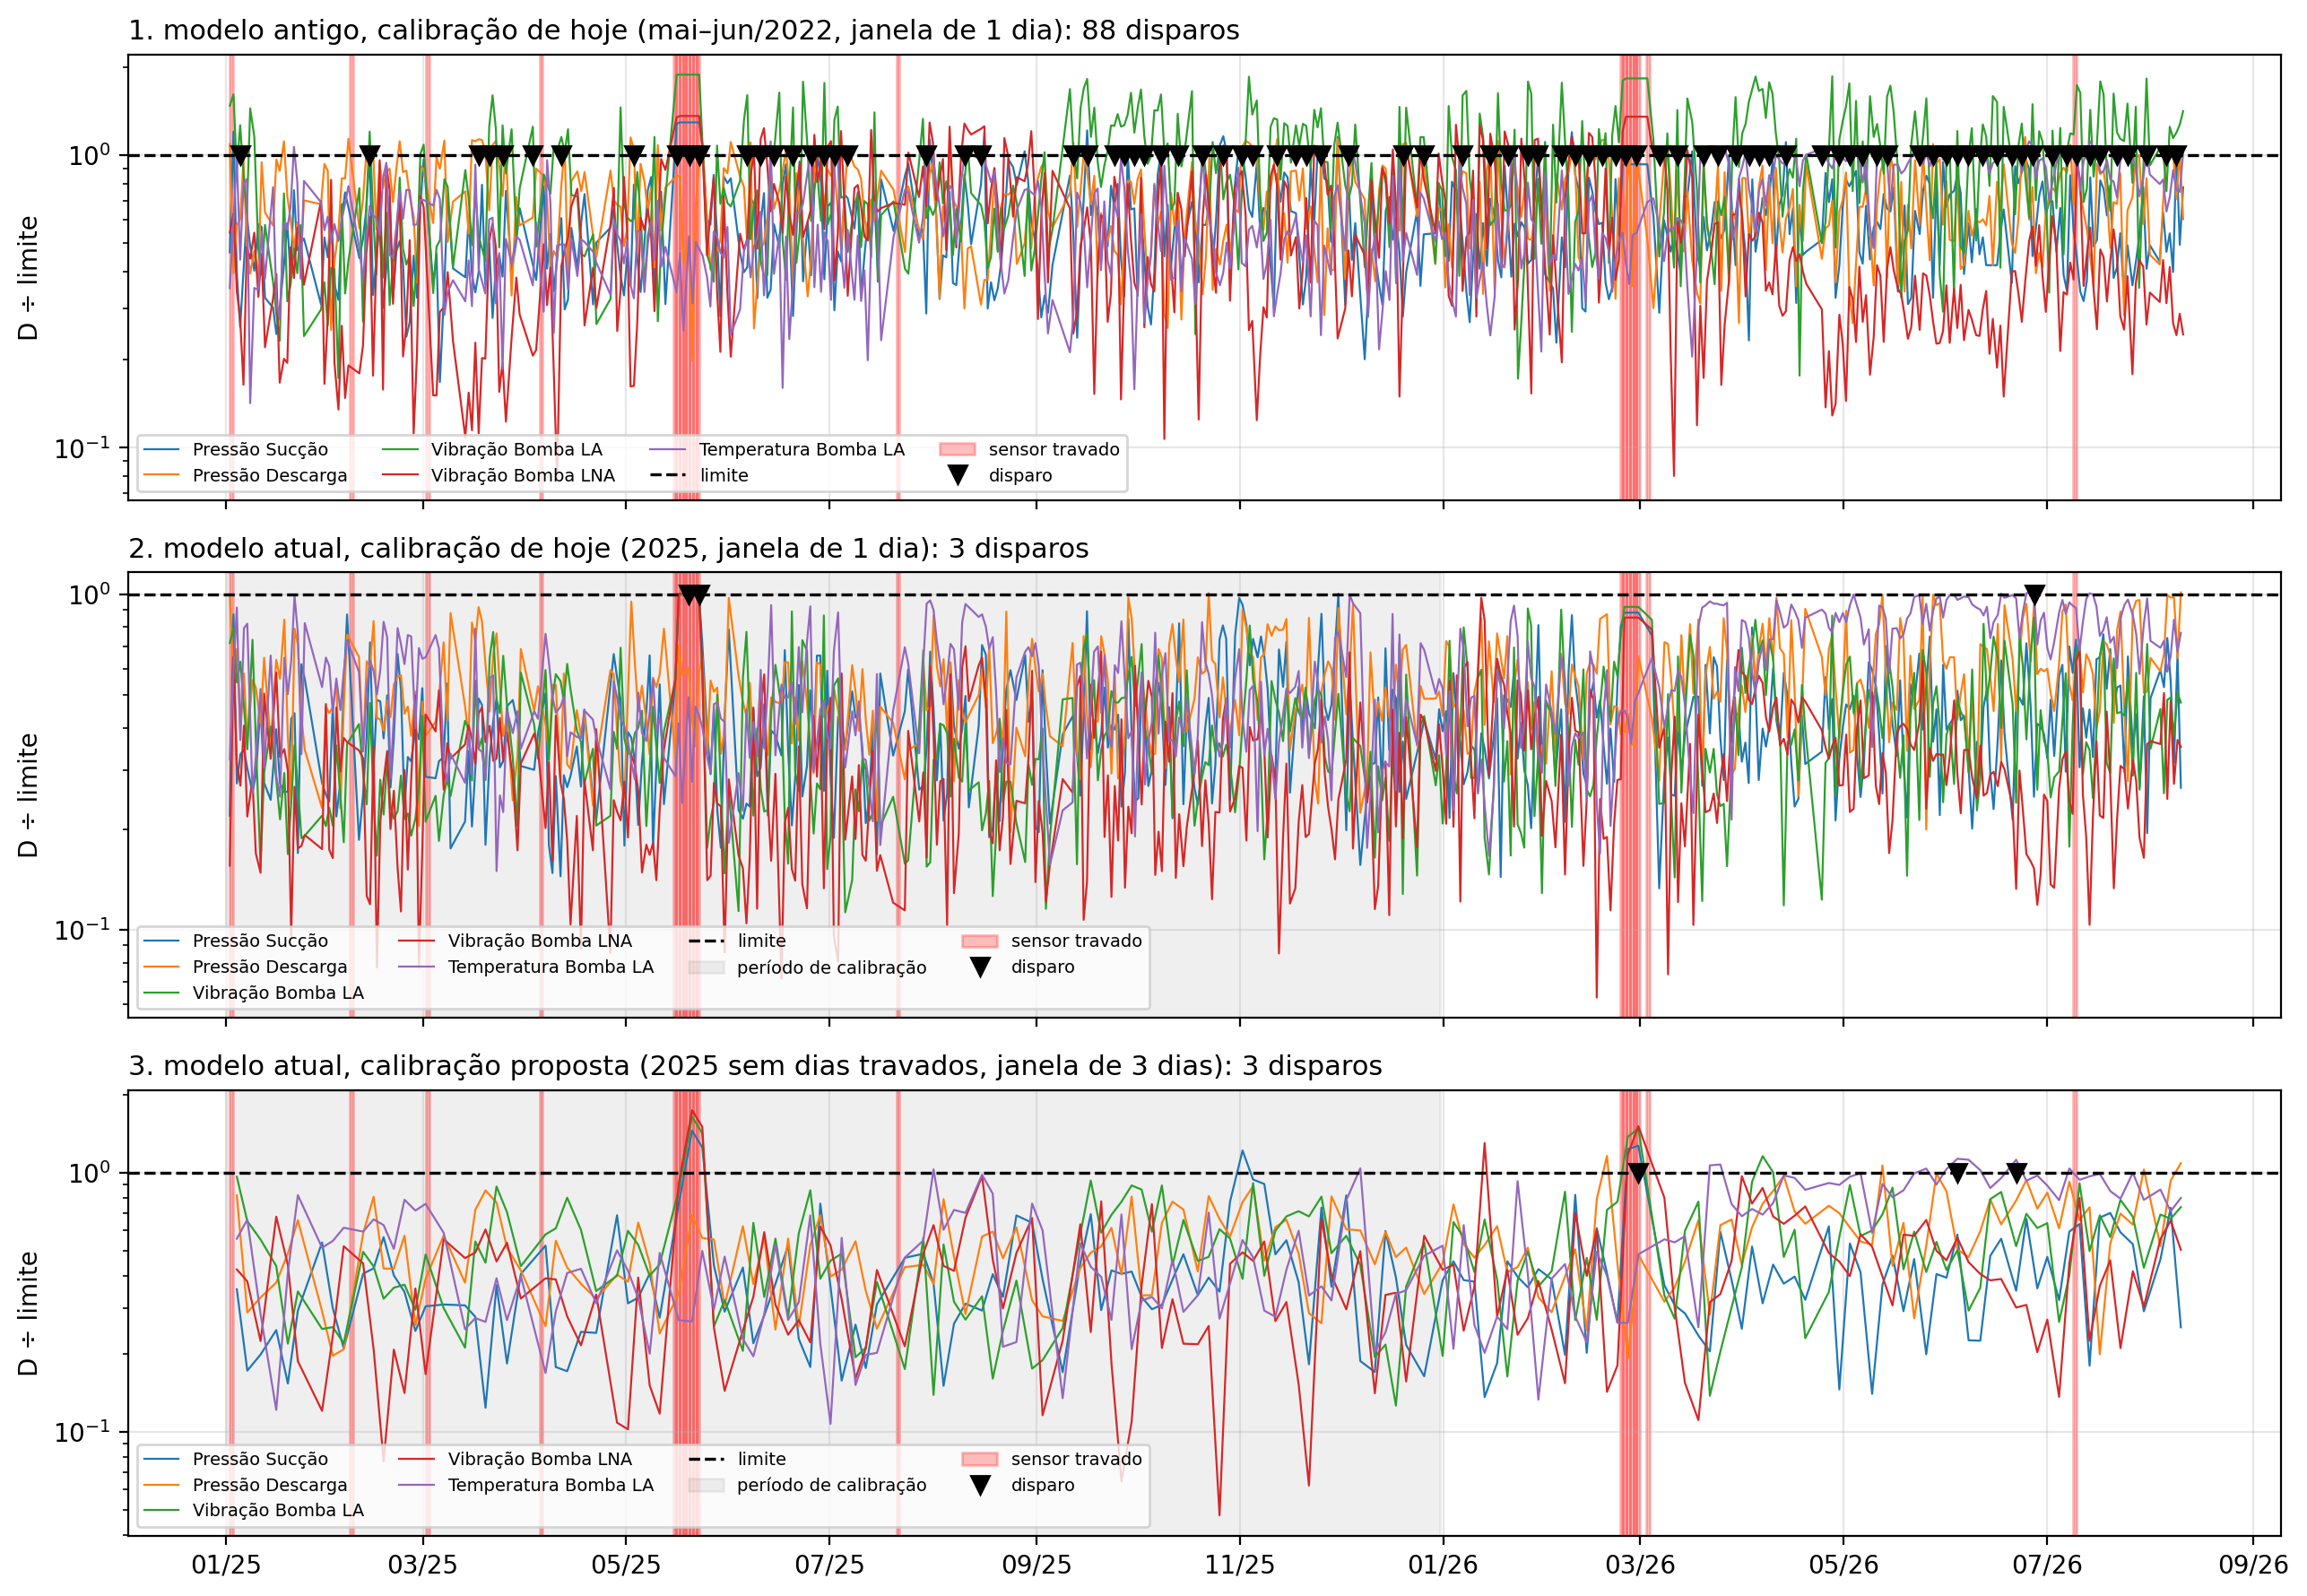

In [12]:
from transpetro_modelos.drift.detectors import CalibratedKSDetector
cols_ks = list(json.loads((B / "drift_ref.json").read_text())["sensors"])
serie_atual = mon._temporal_steps(B, raw)
serie_antigo = mon._temporal_steps(B_ANTIGO, raw)

# dias em que algum sensor ficou travado (mesmo valor o dia inteiro)
dp = serie_atual[cols_ks].groupby(pd.to_datetime(serie_atual.index.date)).std()
dias_travados = dp.index[(dp == 0).any(axis=1)]
ref_prop = serie_atual.loc[:"2025-12-31"]
ref_prop = ref_prop[~pd.to_datetime(ref_prop.index.date).isin(dias_travados)]

def roda(det, serie):
    d, disp = det.scan(serie[det.feature_names])
    return d / np.asarray(det.d_crit), disp, det

ks_casos = {
    "1. modelo antigo, calibração de hoje (mai–jun/2022, janela de 1 dia)":
        roda(CalibratedKSDetector.from_drift_ref(B_ANTIGO / "drift_ref.json"), serie_antigo) + ("2022",),
    "2. modelo atual, calibração de hoje (2025, janela de 1 dia)":
        roda(CalibratedKSDetector.from_drift_ref(B / "drift_ref.json"), serie_atual) + ("2025",),
    "3. modelo atual, calibração proposta (2025 sem dias travados, janela de 3 dias)":
        roda(CalibratedKSDetector(ref_prop[cols_ks], window_size=3 * 288, k_consecutive=3, persistence_window=5,
                                  n_reference=mon.M6_NREF, seed=0), serie_atual) + ("2025",),
}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (nome, (razao, disp, det, ano_ref)) in zip(axes, ks_casos.items()):
    for c in razao.columns:
        ax.plot(razao.index, razao[c], linewidth=0.8, label=c)
    ax.axhline(1, color="black", linestyle="--", linewidth=1.2, label="limite")
    if ano_ref == "2025":
        ax.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"), color="gray", alpha=0.12, label="período de calibração")
    for i, d in enumerate(dias_travados):
        ax.axvspan(d, d + pd.Timedelta(days=1), color="red", alpha=0.25, label="sensor travado" if i == 0 else None)
    for i, (t, s) in enumerate(disp):
        ax.plot(t, 1.0, marker="v", color="black", markersize=7, linestyle="none", label="disparo" if i == 0 else None)
    ax.set_yscale("log"); ax.set_ylabel("D ÷ limite"); ax.grid(alpha=0.3)
    ax.set_title(nome + f": {len(disp)} disparo{'s' if len(disp) != 1 else ''}", loc="left", fontsize=11)
    ax.legend(loc="lower left", fontsize=7, ncol=4)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%y")); plt.tight_layout(); plt.show()

In [13]:
def descreve(disp):
    return "; ".join(f"{t:%d/%m/%Y} ({', '.join(s)})" for t, s in disp) or "nenhum"

_, disp_hoje, det_hoje, _ = ks_casos["2. modelo atual, calibração de hoje (2025, janela de 1 dia)"]
_, disp_prop, det_prop, _ = ks_casos["3. modelo atual, calibração proposta (2025 sem dias travados, janela de 3 dias)"]
_, disp_antigo, _, _ = ks_casos["1. modelo antigo, calibração de hoje (mai–jun/2022, janela de 1 dia)"]

# o mesmo caso real de 2025 com a janela de 3 dias (referência de 2022, como a de hoje)
ref22 = json.loads((B_ANTIGO / "drift_ref.json").read_text())["reference_window"]
s22 = mon._temporal_steps(B_ANTIGO, raw22).loc[ref22[0]:ref22[1]]
_, disp_antigo3 = CalibratedKSDetector(s22[cols_ks], window_size=3 * 288, k_consecutive=3, persistence_window=5,
                                       n_reference=mon.M6_NREF, seed=0).scan(serie_antigo[cols_ks])
atraso = lambda disp: f"{(disp[0][0] - serie_antigo.index.min()).days} dias"

pega = lambda disp, ini, fim: "sim" if any(pd.Timestamp(ini) <= t <= pd.Timestamp(fim) for t, _ in disp) else "não"
pd.DataFrame({
    "calibração de hoje (1 dia)": [", ".join(f"{c}: {v:.2f}" for c, v in zip(cols_ks, det_hoje.d_crit)),
                                   atraso(disp_antigo), pega(disp_hoje, "2025-01-01", "2025-12-31"),
                                   pega(disp_hoje, "2026-02-23", "2026-03-10"), pega(disp_hoje, "2026-04-01", "2026-08-10"),
                                   descreve([d for d in disp_hoje if d[0] >= pd.Timestamp("2026-01-01")])],
    "calibração proposta (3 dias, sem travados)": [", ".join(f"{c}: {v:.2f}" for c, v in zip(cols_ks, det_prop.d_crit)),
                                   atraso(disp_antigo3), pega(disp_prop, "2025-01-01", "2025-12-31"),
                                   pega(disp_prop, "2026-02-23", "2026-03-10"), pega(disp_prop, "2026-04-01", "2026-08-10"),
                                   descreve([d for d in disp_prop if d[0] >= pd.Timestamp("2026-01-01")])],
}, index=["limite por sensor (máximo possível = 1)", "atraso na mudança de conceito real de 2025",
          "dispara dentro de 2025 (período de calibração)", "pega o sensor travado de fev–mar/2026",
          "pega a temperatura do mancal LA mais fria em 2026", "disparos em 2026"])

,calibração de hoje (1 dia),"calibração proposta (3 dias, sem travados)"
limite por sensor (máximo possível = 1),"Pressão Sucção: 0.98, Pressão Descarga: 0.96, ...","Pressão Sucção: 0.69, Pressão Descarga: 0.69, ..."
atraso na mudança de conceito real de 2025,4 dias,9 dias
dispara dentro de 2025 (período de calibração),sim,não
pega o sensor travado de fev–mar/2026,não,sim
pega a temperatura do mancal LA mais fria em 2026,sim,sim
disparos em 2026,27/06/2026 (Temperatura Bomba LA),"28/02/2026 (Pressão Descarga, Pressão Sucção, ..."


**Leitura.**
- **Modelo antigo (1):** a mudança de conceito real aparece com clareza. Os sensores passam do limite logo em
  jan/2025 e ficam acima dele quase o tempo todo.
- **Modelo atual, calibração de hoje (2):** as curvas ficam quase sempre bem abaixo de 1, mas o limite é quase o
  máximo possível. A referência de 2025 inclui dias com sensor travado, e um dia só de operação ocupa uma faixa
  estreita comparado com o ano todo, com estações e regimes. Resultado: ele pega o travamento de mai/2025 (que está
  dentro da própria calibração) e a temperatura de 2026, mas não pega o travamento de fev–mar/2026.
- **Calibração proposta (3):** com janela de 3 dias e sem os dias travados, os limites caem e o KS pega os dois
  eventos de 2026, sem disparar em 2025. O custo é o atraso no caso real de 2025, que sobe de 4 para 9 dias, ainda
  bem antes do semáforo semanal (vermelho na 4ª semana).

**Cuidado:** a proposta foi escolhida olhando estes mesmos dados. Antes de trocar o `drift_ref.json` do modelo em
produção, vale repetir o teste em outro equipamento (B-4064A, que tem mudança de conceito conhecida).

## Slide 9 — Próximos passos
1. **Ligar a regra de 1 hora na produção:** já aplicada nos números deste notebook; falta ativar no pacote que
   roda no equipamento.
2. **Testar o monitor por 4 semanas:** ele roda toda semana junto com o modelo, só registrando os avisos, sem
   acionar retreino. Se nesse período ele não der aviso falso, passa a valer.
3. **Verificar com a operação** o alerta de 17/01 (vibração) e a temperatura do mancal LA abaixo de 2025 desde
   abril.
4. **Levar para outro equipamento:** repetir a validação onde houver histórico de falha.

## Apoio ao passo 3 — o motivo de cada alarme de 2026

Esta parte não está nos slides: é o material para verificar com a operação o alerta de 2026 e entender os 2
alarmes curtos que a regra de 1 hora descartou. Usa o modelo
em produção, o mais recente (`B-8802B-2025`, treinado com 2025).

Os trechos com a bomba parada (pressão de descarga abaixo de 35 bar) e os 90 minutos depois de cada religada
são filtrados antes do modelo: nesses momentos não há erro nem alarme. Nas figuras eles aparecem em cinza, e a
linha do "esperado pelo modelo" fica vazia.

O modelo recebe 5 sensores e devolve o valor que **esperava** para cada um, dado o comportamento conjunto dos
outros. O erro de cada sensor é a diferença entre o que ele mediu e o que o modelo esperava. O alerta sai quando
a soma desses erros fica alta. Então, para saber o motivo de um alerta, olhamos:
1. **quanto cada sensor pesou no erro** durante o alerta;
2. **o valor medido contra o esperado** pelo modelo e contra o típico de 2025.

In [14]:
import pickle, torch
X26 = si.preprocessar(B, raw)                       # os 5 sensores do modelo, normalizados como no treino
torch.manual_seed(0)
with torch.no_grad():
    rec = modelo(torch.tensor(X26.values, dtype=torch.float32))[0].numpy()
erro_sensor = pd.DataFrame((rec - X26.values) ** 2, index=X26.index, columns=X26.columns)
scaler = pickle.load(open(B / "scaler.pkl", "rb"))
esperado = pd.DataFrame(scaler.inverse_transform(rec), index=X26.index, columns=X26.columns)   # em unidades físicas
tipico = raw.loc["2025"][raw.loc["2025", "Pressão Descarga"] > 35][X26.columns].median()
UN = {"Pressão Sucção": "bar", "Pressão Descarga": "bar", "Vibração Bomba LA": "mm/s",
      "Vibração Bomba LNA": "mm/s", "Temperatura Bomba LA": "°C"}

# janela de cada alerta: o alarme inteiro (desde o começo, não só a partir da 1ª hora)
alarmes = episodios(al26_sem_regra)
tabelas = []
for a, b in alarmes:
    w = slice(a - pd.Timedelta(hours=2), b)         # inclui as 2 h antes: a persistência liga o alarme com atraso
    peso = 100 * erro_sensor.loc[w].mean() / erro_sensor.loc[w].mean().sum()
    medido = raw[X26.columns].reindex(X26.loc[w].index).mean()
    t = pd.DataFrame({"peso no erro (%)": peso.round(0), "medido": medido.round(2),
                      "esperado pelo modelo": esperado.loc[w].mean().astype(float).round(2), "típico em 2025": tipico.round(2),
                      "unidade": pd.Series(UN)}).sort_values("peso no erro (%)", ascending=False)
    tabelas.append(t)
    regra = "vira alerta" if al26[a:b].any() else "descartado pela regra de 1 h"
    print(f"\nalarme {a:%d/%m/%Y %H:%M} → {b:%H:%M} ({(b - a).total_seconds() / 3600:.1f} h): {regra}")
    display(t)


alarme 17/01/2026 21:30 → 22:40 (1.2 h): vira alerta


,peso no erro (%),medido,esperado pelo modelo,típico em 2025,unidade
Vibração Bomba LA,36.0,3.59,3.03,2.33,mm/s
Vibração Bomba LNA,34.0,1.28,1.09,0.90,mm/s
Pressão Descarga,15.0,52.90,51.22,49.38,bar
Pressão Sucção,10.0,3.80,4.16,4.11,bar
Temperatura Bomba LA,4.0,47.90,49.10,53.08,°C



alarme 24/07/2026 14:35 → 14:55 (0.3 h): descartado pela regra de 1 h


,peso no erro (%),medido,esperado pelo modelo,típico em 2025,unidade
Vibração Bomba LA,47.0,1.71,2.13,2.33,mm/s
Temperatura Bomba LA,36.0,43.68,47.36,53.08,°C
Vibração Bomba LNA,10.0,0.98,0.91,0.90,mm/s
Pressão Sucção,6.0,4.70,4.50,4.11,bar
Pressão Descarga,1.0,49.44,49.66,49.38,bar



alarme 10/08/2026 13:20 → 14:00 (0.7 h): descartado pela regra de 1 h


,peso no erro (%),medido,esperado pelo modelo,típico em 2025,unidade
Temperatura Bomba LA,34.0,44.66,48.45,53.08,°C
Vibração Bomba LNA,22.0,1.13,1.02,0.90,mm/s
Vibração Bomba LA,19.0,1.80,2.07,2.33,mm/s
Pressão Sucção,15.0,2.72,3.32,4.11,bar
Pressão Descarga,11.0,53.92,52.31,49.38,bar


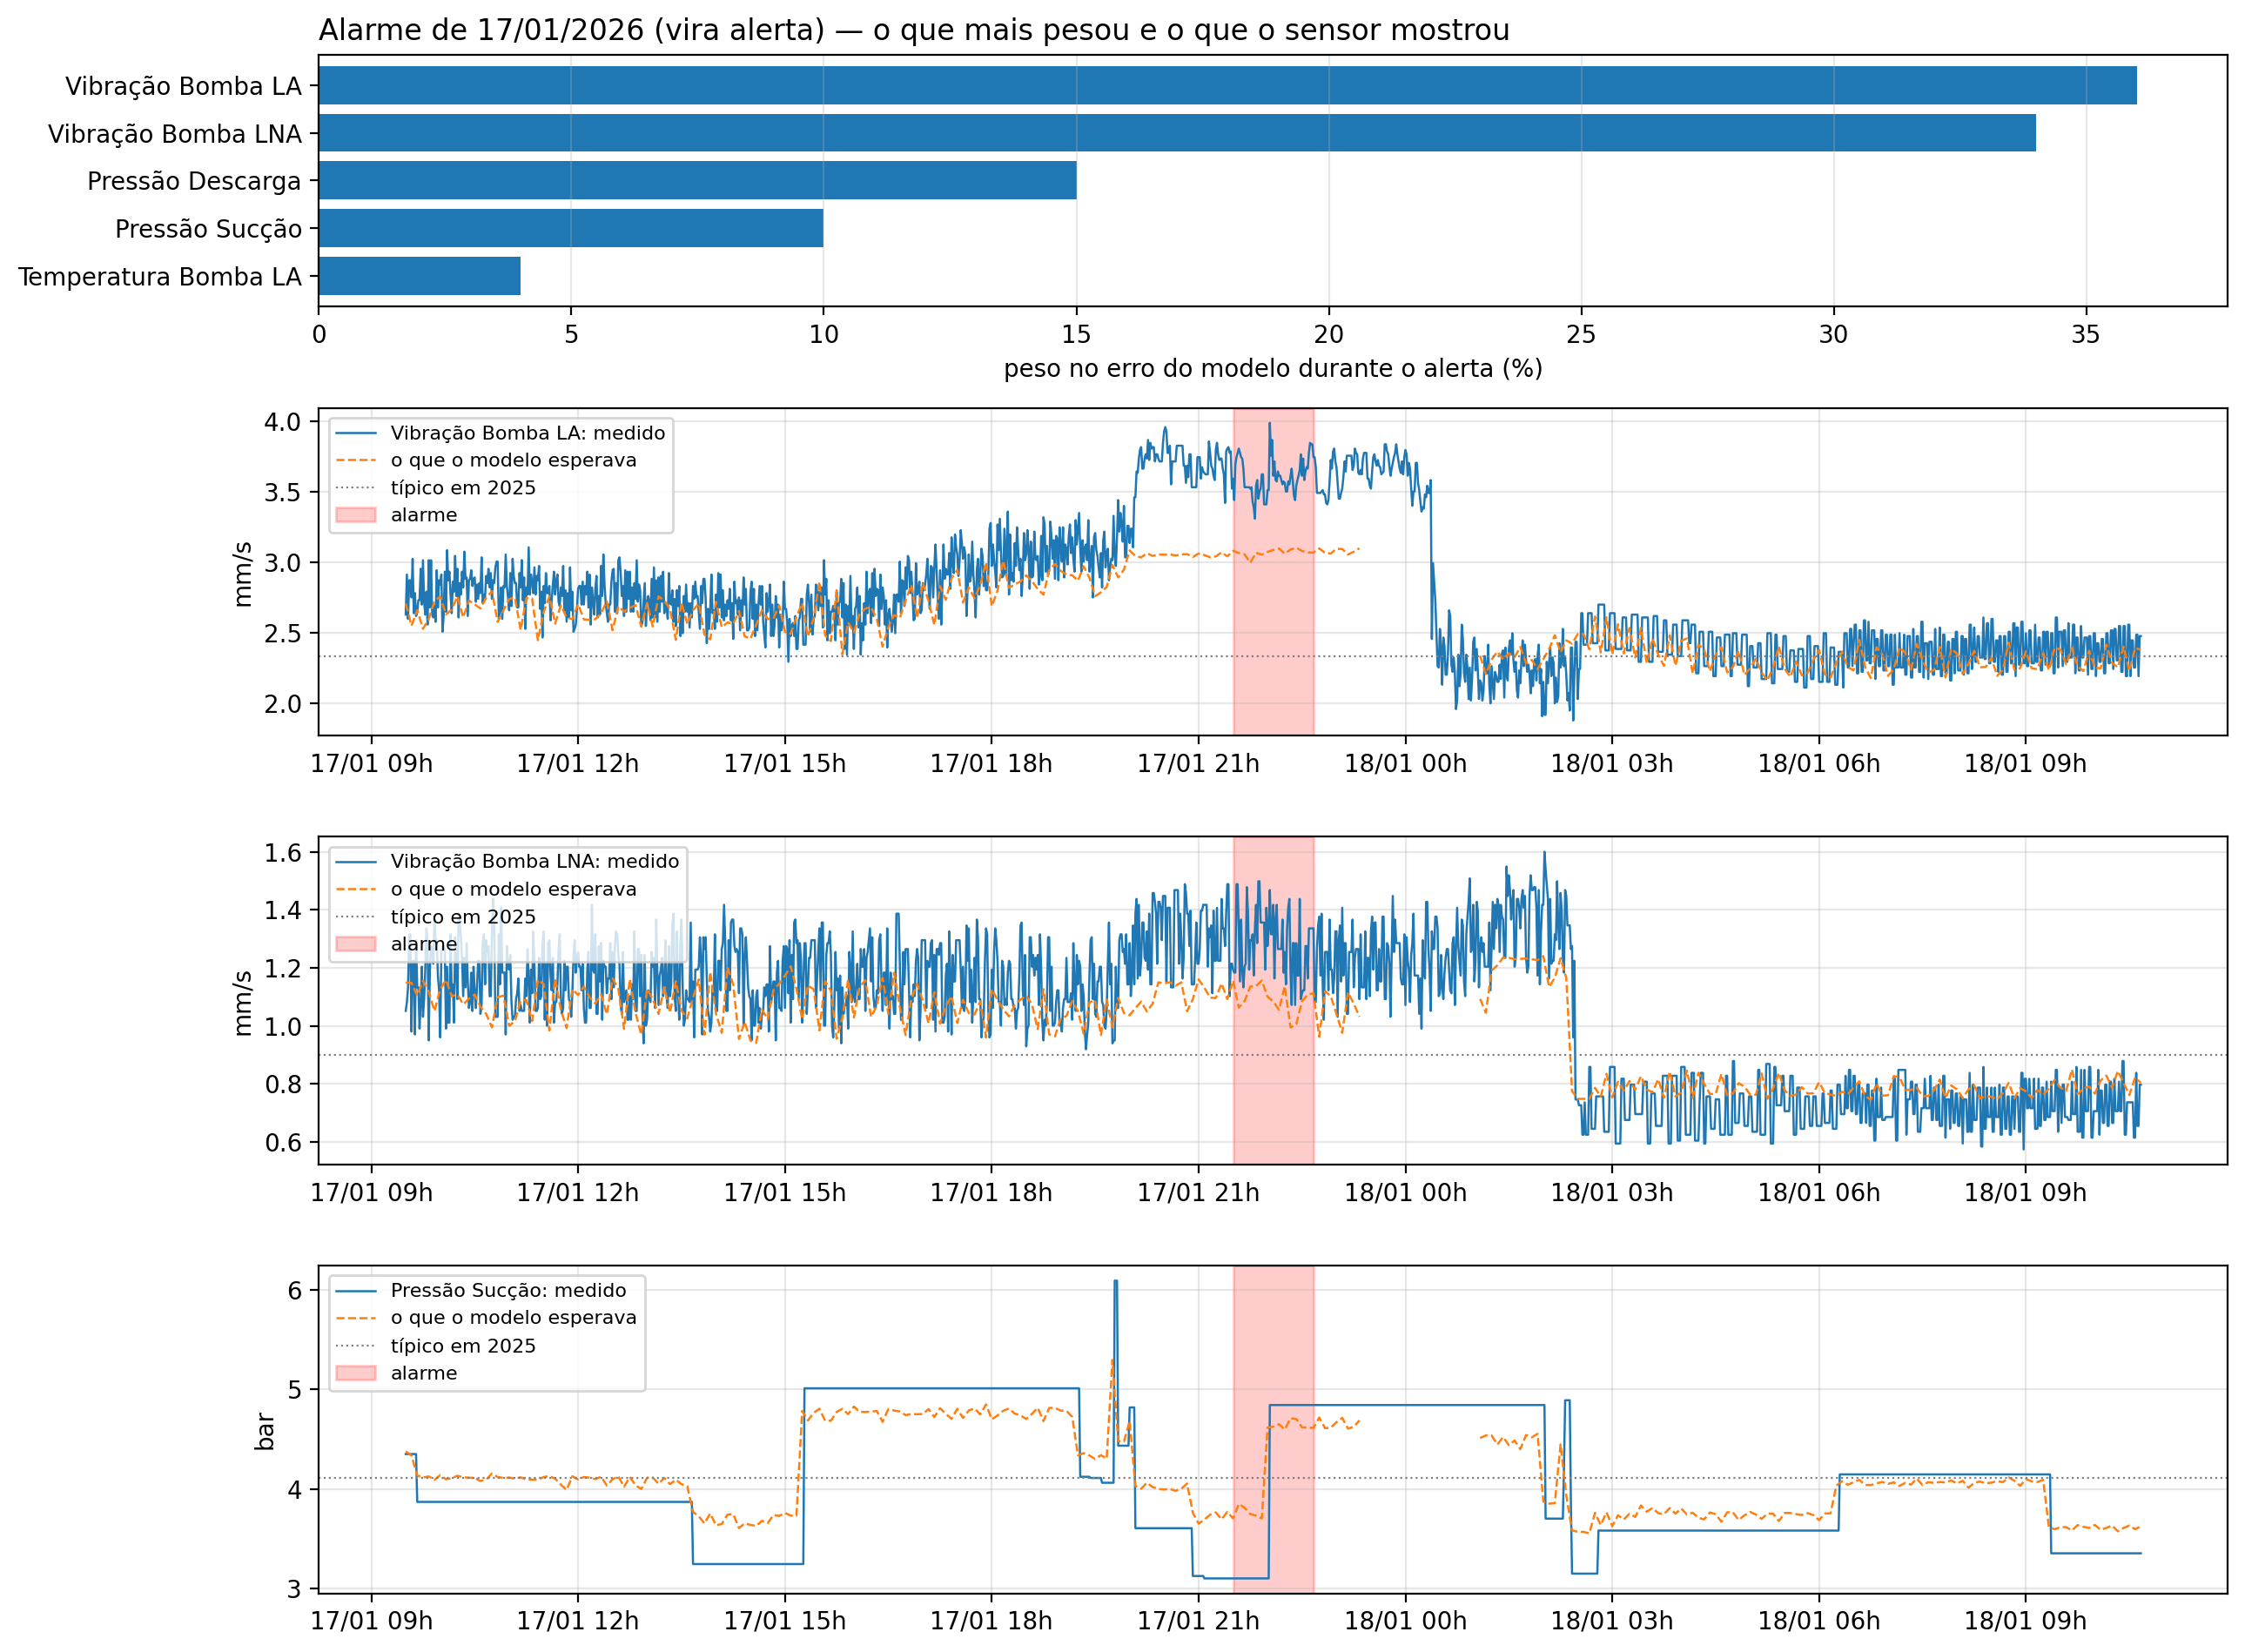

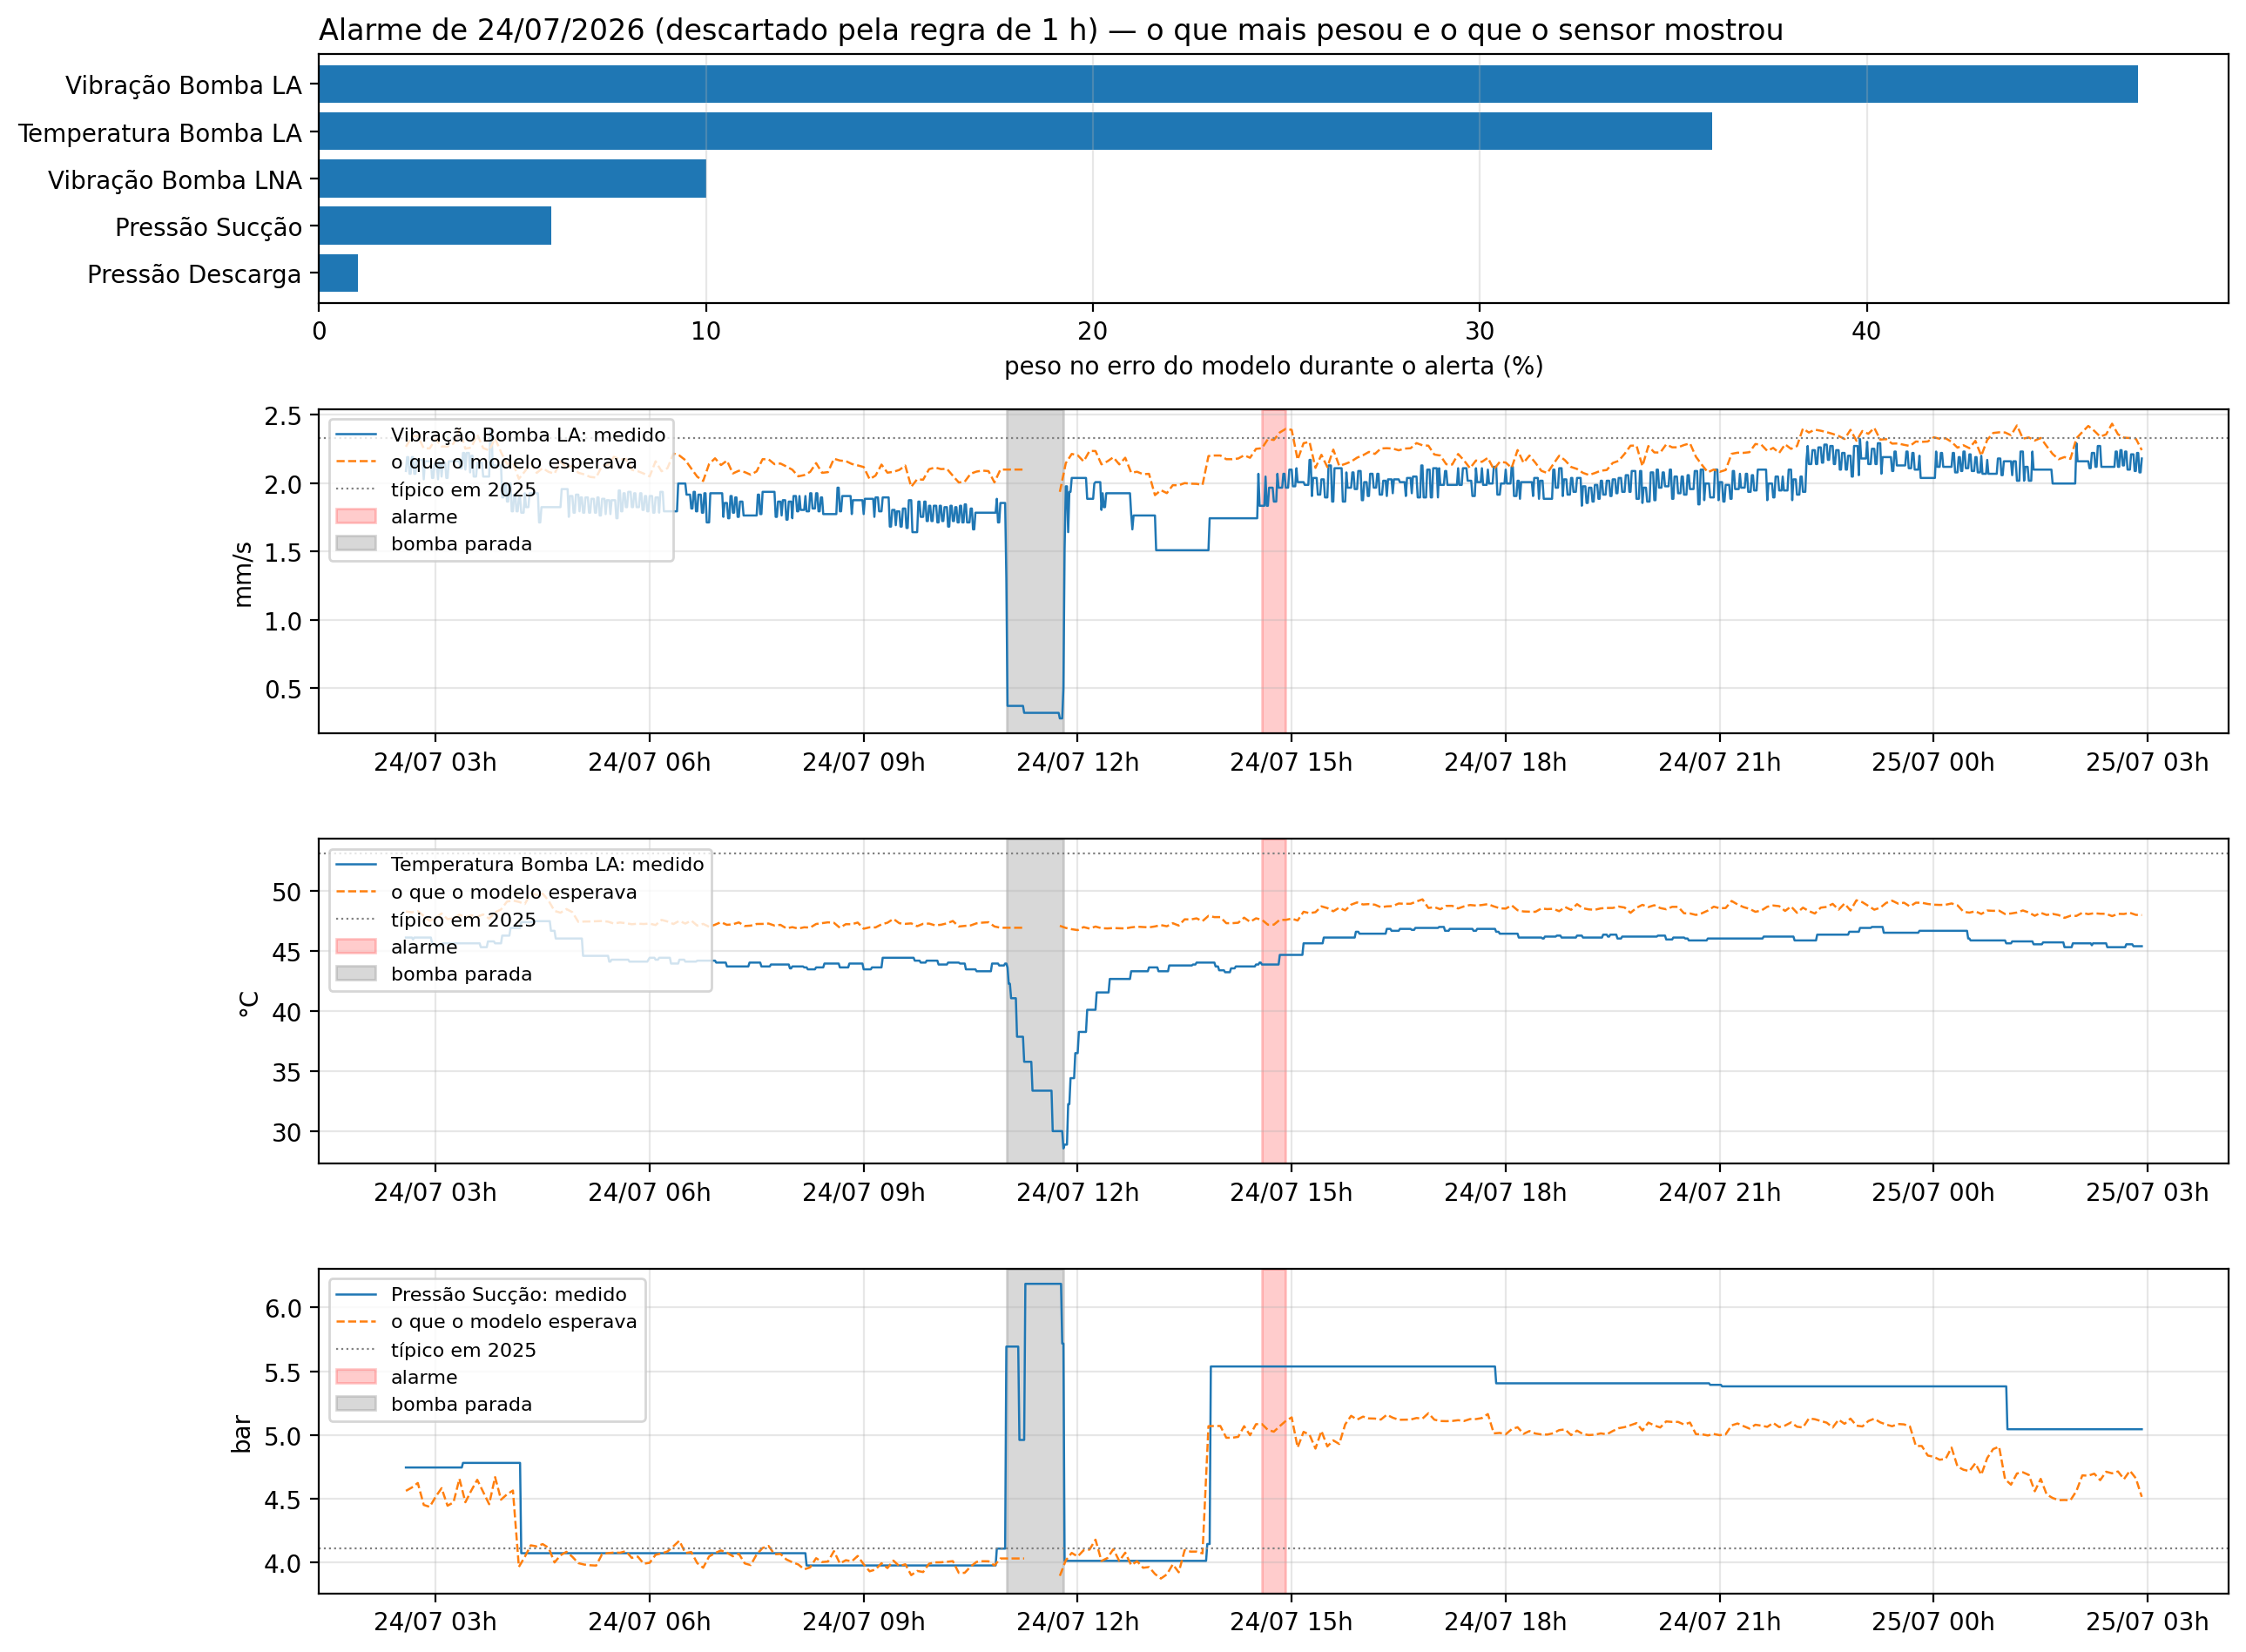

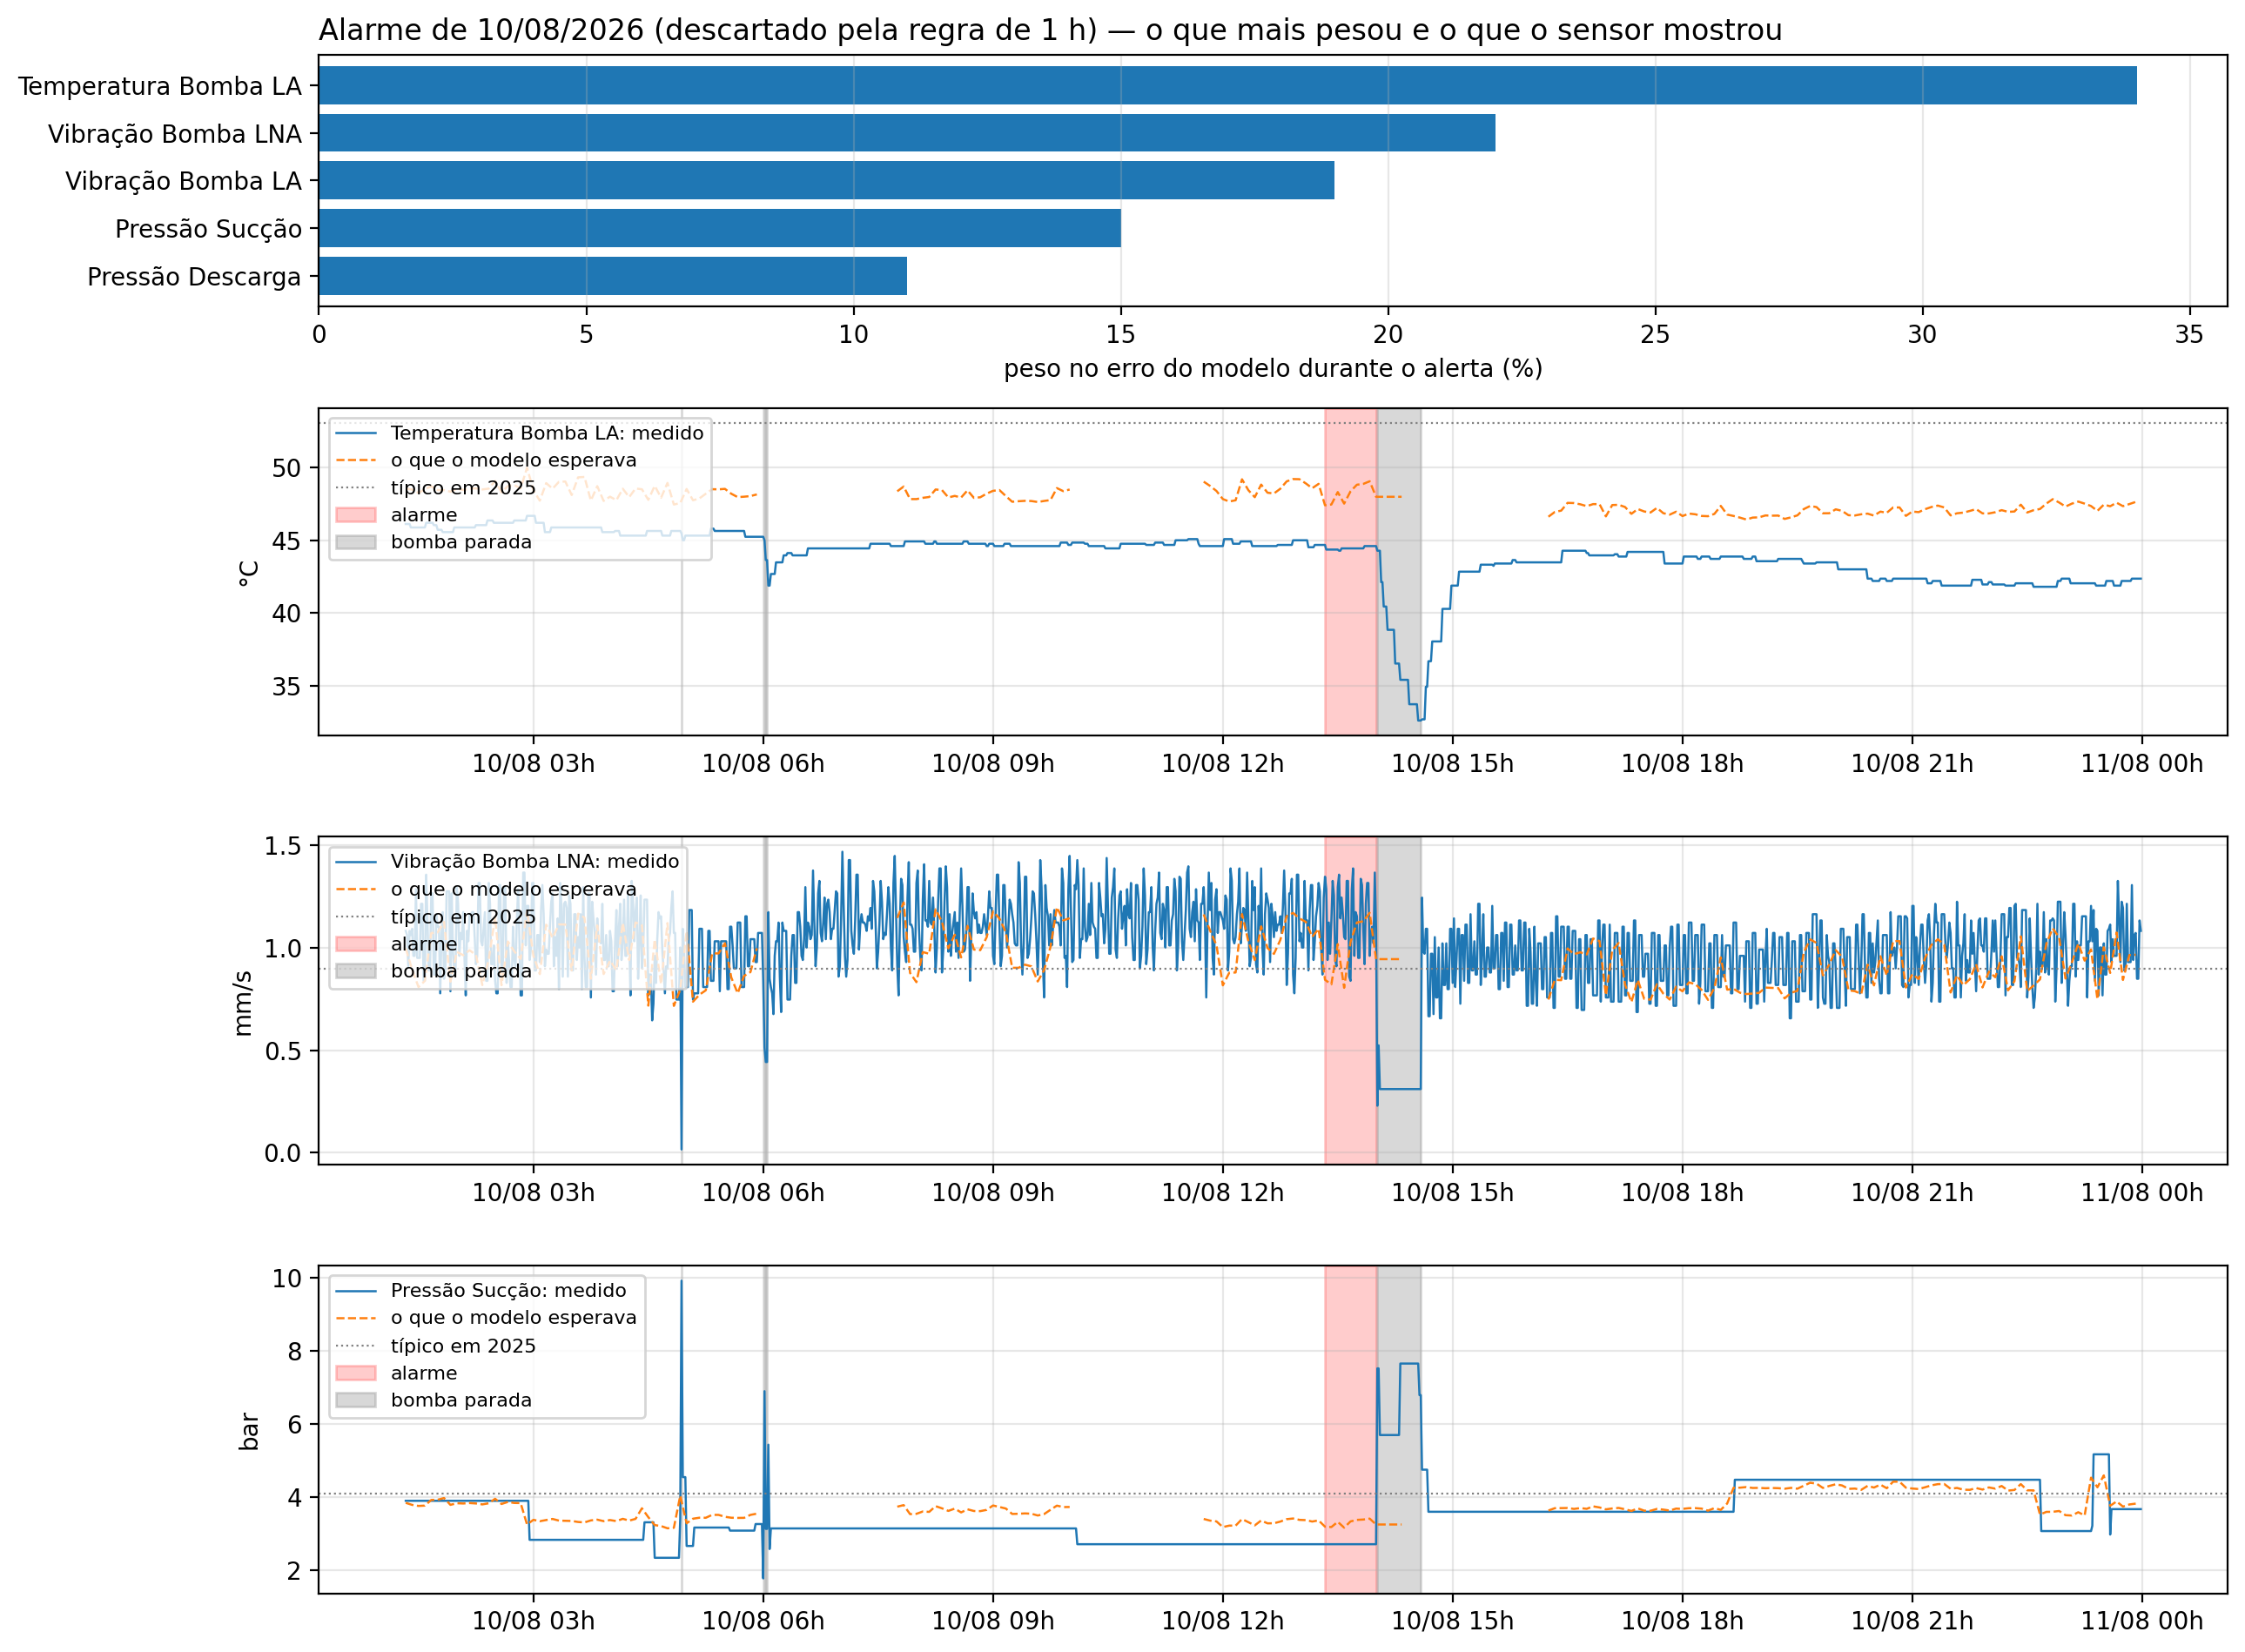

In [15]:
for (a, b), t in zip(alarmes, tabelas):
    principais = list(t.index[:2]) + (["Pressão Sucção"] if "Pressão Sucção" not in t.index[:2] else [])
    ini, fim = a - pd.Timedelta(hours=12), b + pd.Timedelta(hours=12)
    fig, axes = plt.subplots(1 + len(principais), 1, figsize=(13, 2.4 * (1 + len(principais))), sharex=False,
                             gridspec_kw={"height_ratios": [1] + [1.3] * len(principais)})
    axes[0].barh(t.index[::-1], t["peso no erro (%)"][::-1])
    axes[0].set_xlabel("peso no erro do modelo durante o alerta (%)"); axes[0].grid(alpha=0.3, axis="x")
    regra = "vira alerta" if al26[a:b].any() else "descartado pela regra de 1 h"
    axes[0].set_title(f"Alarme de {a:%d/%m/%Y} ({regra}) — o que mais pesou e o que o sensor mostrou", loc="left")
    for ax, c in zip(axes[1:], principais):
        m_ = raw.loc[ini:fim, c]
        ax.plot(m_.index, m_, linewidth=0.9, label=f"{c}: medido")
        e_ = esperado.loc[ini:fim, c].asfreq("5min")          # pontos filtrados ficam vazios (a linha quebra)
        ax.plot(e_.index, e_, linewidth=0.9, linestyle="--",
                label="o que o modelo esperava")
        ax.axhline(tipico[c], color="gray", linewidth=0.8, linestyle=":", label="típico em 2025")
        ax.axvspan(a, b, color="red", alpha=0.2, label="alarme")
        parada = raw.loc[ini:fim, "Pressão Descarga"] < 35
        for j, (_, e) in enumerate(parada[parada].groupby((~parada).cumsum())):
            ax.axvspan(e.index.min(), e.index.max(), color="gray", alpha=0.3, label="bomba parada" if j == 0 else None)
        ax.set_ylabel(UN[c]); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    plt.tight_layout(); plt.show()

Nos alarmes de 24/07 e 10/08 a temperatura do mancal LA estava abaixo do esperado. Vale saber se isso foi
pontual ou vinha de antes. A tabela abaixo
compara a mediana mensal da temperatura do mancal LA (bomba operando) em 2026 com a de 2025.

In [16]:
op = raw[raw["Pressão Descarga"] > 35]["Temperatura Bomba LA"]
mens = pd.DataFrame({"2025": op.loc["2025"].groupby(op.loc["2025"].index.month).median(),
                     "2026": op.loc["2026"].groupby(op.loc["2026"].index.month).median()})
mens["diferença (°C)"] = mens["2026"] - mens["2025"]
mens.index.name = "mês"; mens.round(1)

,2025,2026,diferença (°C)
mês,,,
1,55.3,51.2,-4.1
2,55.8,52.5,-3.3
3,53.2,52.1,-1.1
4,53.5,47.4,-6.1
5,53.2,46.4,-6.8
6,52.3,44.7,-7.6
7,49.9,45.5,-4.4
8,49.2,48.0,-1.3
9,51.1,NaN,NaN


### O que os dados mostram em cada alerta

**17/01/2026, 21:30 → 22:40 (vibração).** Às 20h a vibração dos dois mancais da bomba subiu de uma vez: LA de
3,0 para 3,7 mm/s, LNA de 1,1 para 1,3 mm/s. O modelo esperava cerca de 3,0 e 1,1 para aquelas condições. No
mesmo horário a pressão de sucção vinha caindo (de 5,0 bar às 19h para 3,1 bar às 21h). A sucção voltou a 4,8 bar
às 22h, mas a vibração continuou alta até perto da meia-noite, quando caiu sozinha para 2,2 mm/s. Os dois mancais
juntos pesaram 70 % do erro.

> Anomalia real nos sensores: vibração dos dois mancais da bomba acima do esperado entre 20h e 00h de 17/01,
> começando junto com uma queda da pressão de sucção. Pode indicar cavitação ou operação fora do ponto usual;
> favor verificar se houve manobra ou troca de tanque nesse horário.

**24/07/2026 e 10/08/2026 (descartados pela regra de 1 hora).** Os dois têm o mesmo padrão: temperatura do
mancal LA uns 4 °C abaixo do que o modelo esperava (cerca de 44 contra 48 °C) e vibração LA um pouco abaixo
também, sem nenhum sensor fora da faixa normal. Em 10/08 a pressão de sucção também estava baixa (2,7 bar). Os
alarmes duraram 20 e 40 minutos. Em 10/08 a bomba parou logo depois, por volta das 14h, e o alarme acabou ali.

A tabela mensal mostra que a temperatura do mancal LA está abaixo de 2025 desde o começo de 2026, chegando a
7,6 °C abaixo em junho. Os dois alarmes curtos são o ponto em que essa tendência lenta encostou no limite, e não
um evento. Não viram alerta, mas a tendência vale uma pergunta à operação:

> A temperatura do mancal LA da bomba está de 4 a 8 °C abaixo de 2025 desde abril. Pode indicar mudança na
> refrigeração ou lubrificação do mancal, ou desvio do sensor de temperatura; favor verificar.

**Uma correção na conta.** Uma versão anterior deste notebook mostrava 10/08 como alerta de 3,7 h. Isso vinha de
dois efeitos das paradas da bomba, que já estão tratados em `alertas()`: a persistência de 15 de 20 pontos
juntava pontos de antes e de depois de uma parada, e o `ffill` do pipeline repete o último valor por até 20 min
dentro de cada parada. Contando só medição real, com a bomba ligada, o alarme de 10/08 durou 40 minutos.